# Partie I — Fusion nucléaire et nucléosynthèse

## Notebook I.1 — Physique de la fusion nucléaire

### Objectif général

Ce notebook présente les fondements physiques et mathématiques nécessaires
à l’étude de la fusion nucléaire dans les étoiles.

Les calculs reposent principalement sur :

- AME2020 pour les masses atomiques et les énergies nucléaires ;
- NUBASE2020 pour les propriétés des noyaux ;
- CODATA 2022 pour les constantes physiques fondamentales.

La base JINA REACLIB sera principalement utilisée dans les notebooks suivants,
consacrés aux chaînes de réactions et aux taux thermonucléaires.

### Principe méthodologique

Le notebook distingue explicitement :

1. la physique nucléaire établie ;
2. les calculs numériques dérivés des données officielles ;
3. les observables exploratoires GVH, introduites seulement après validation
   des résultats physiques standards.

In [186]:
from pathlib import Path
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("default")

print("Environnement scientifique chargé avec succès.")

Environnement scientifique chargé avec succès.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [187]:
from pathlib import Path

print(Path.cwd())

/content


In [188]:
from pathlib import Path
import subprocess
import shutil

URL_DEPOT = "https://github.com/col38470682/Univers.git"
DOSSIER_DEPOT = Path("/content/Univers")

# Nettoyage éventuel d'un dossier incomplet créé lors d'une tentative précédente
if DOSSIER_DEPOT.exists() and not (DOSSIER_DEPOT / ".git").exists():
    shutil.rmtree(DOSSIER_DEPOT)

# Clonage du dépôt
if not DOSSIER_DEPOT.exists():
    subprocess.run(
        ["git", "clone", URL_DEPOT, str(DOSSIER_DEPOT)],
        check=True
    )
    print("Dépôt cloné avec succès.")
else:
    print("Le dépôt est déjà présent dans Colab.")

# Chemins scientifiques du projet
RACINE_DEPOT = DOSSIER_DEPOT / "gvh_dynamic"

DOSSIER_NUCLEAR = RACINE_DEPOT / "Data" / "Nuclear"
DOSSIER_AME2020 = DOSSIER_NUCLEAR / "AME2020"
DOSSIER_CODATA = DOSSIER_NUCLEAR / "CODATA"
DOSSIER_REACLIB = DOSSIER_NUCLEAR / "REACLIB"

print("\nChemins détectés :")
print("Dépôt GitHub      :", DOSSIER_DEPOT)
print("Racine GVH        :", RACINE_DEPOT)
print("Données nucléaires:", DOSSIER_NUCLEAR)
print("AME2020           :", DOSSIER_AME2020)
print("CODATA            :", DOSSIER_CODATA)
print("REACLIB           :", DOSSIER_REACLIB)

Le dépôt est déjà présent dans Colab.

Chemins détectés :
Dépôt GitHub      : /content/Univers
Racine GVH        : /content/Univers/gvh_dynamic
Données nucléaires: /content/Univers/gvh_dynamic/Data/Nuclear
AME2020           : /content/Univers/gvh_dynamic/Data/Nuclear/AME2020
CODATA            : /content/Univers/gvh_dynamic/Data/Nuclear/CODATA
REACLIB           : /content/Univers/gvh_dynamic/Data/Nuclear/REACLIB


In [189]:
verification = {
    "Dépôt Univers": DOSSIER_DEPOT.exists(),
    "gvh_dynamic": RACINE_DEPOT.exists(),
    "Data/Nuclear": DOSSIER_NUCLEAR.exists(),
    "AME2020": DOSSIER_AME2020.exists(),
    "CODATA": DOSSIER_CODATA.exists(),
    "REACLIB": DOSSIER_REACLIB.exists(),
}

for nom, existe in verification.items():
    symbole = "✅" if existe else "❌"
    print(f"{symbole} {nom}: {existe}")

✅ Dépôt Univers: True
✅ gvh_dynamic: True
✅ Data/Nuclear: True
✅ AME2020: True
✅ CODATA: True
✅ REACLIB: True


In [190]:
for nom, dossier in {
    "AME2020": DOSSIER_AME2020,
    "CODATA": DOSSIER_CODATA,
    "REACLIB": DOSSIER_REACLIB,
}.items():
    print(f"\n--- {nom} ---")

    fichiers = sorted(f for f in dossier.iterdir() if f.is_file())

    if not fichiers:
        print("Aucun fichier trouvé.")
    else:
        for fichier in fichiers:
            print(f"- {fichier.name}")


--- AME2020 ---
- .gitkeep
- AME2020_II_030003.pdf
- AME2020_I_030002.pdf
- NUBASE2020_030001.pdf
- mass_1.mas20.txt
- nubase_4.mas20.txt
- rct1.mas20.txt
- rct2_1.mas20.txt

--- CODATA ---
- .gitkeep
- CODATA2022_All_Values.txt
- CODATA2022_Constants.pdf

--- REACLIB ---
-     REACLIB_Default_Library_2021.dat
- .gitkeep


In [191]:
import shutil
from pathlib import Path
import subprocess

# Supprime l'ancienne copie
shutil.rmtree("/content/Univers", ignore_errors=True)

# Reclone le dépôt
subprocess.run([
    "git",
    "clone",
    "https://github.com/col38470682/Univers.git",
    "/content/Univers"
], check=True)

print("Dépôt mis à jour.")

Dépôt mis à jour.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [192]:
from pathlib import Path

DOSSIER_REACLIB = Path("/content/Univers/gvh_dynamic/Data/Nuclear/REACLIB")

for f in DOSSIER_REACLIB.iterdir():
    print(repr(f.name))

'.gitkeep'
'    REACLIB_Default_Library_2021.dat'


In [193]:
from pathlib import Path

FICHIER_REACLIB = DOSSIER_REACLIB / "    REACLIB_Default_Library_2021.dat"

print(FICHIER_REACLIB.exists())

True


In [194]:
fichiers_reaclib = sorted(
    f for f in DOSSIER_REACLIB.glob("*.dat")
    if f.is_file()
)

if not fichiers_reaclib:
    raise FileNotFoundError(
        f"Aucun fichier REACLIB .dat trouvé dans {DOSSIER_REACLIB}"
    )

FICHIER_REACLIB = fichiers_reaclib[0]

print("Fichier REACLIB détecté :", repr(FICHIER_REACLIB.name))
print("Taille :", FICHIER_REACLIB.stat().st_size, "octets")

Fichier REACLIB détecté : '    REACLIB_Default_Library_2021.dat'
Taille : 2254 octets


In [195]:
FICHIER_CODATA = DOSSIER_CODATA / "CODATA2022_All_Values.txt"

if not FICHIER_CODATA.exists():
    raise FileNotFoundError(
        f"Fichier CODATA introuvable : {FICHIER_CODATA}"
    )

print("Fichier CODATA détecté :", FICHIER_CODATA.name)
print("Taille :", FICHIER_CODATA.stat().st_size, "octets")

with FICHIER_CODATA.open(
    "r",
    encoding="utf-8",
    errors="replace"
) as fichier:
    for numero, ligne in enumerate(fichier, start=1):
        print(f"{numero:02d} | {ligne.rstrip()}")
        if numero >= 20:
            break

Fichier CODATA détecté : CODATA2022_All_Values.txt
Taille : 40801 octets
01 | 
02 |              Fundamental Physical Constants --- Complete Listing
03 |              2022 CODATA adjustment
04 | 
05 | 
06 |   From:  http://physics.nist.gov/constants
07 | 
08 | 
09 | 
10 |   Quantity                                                       Value                 Uncertainty           Unit
11 | -----------------------------------------------------------------------------------------------------------------------------
12 | alpha particle-electron mass ratio                          7294.299 541 71          0.000 000 17
13 | alpha particle mass                                         6.644 657 3450 e-27      0.000 000 0021 e-27      kg
14 | alpha particle mass energy equivalent                       5.971 920 1997 e-10      0.000 000 0019 e-10      J
15 | alpha particle mass energy equivalent in MeV                3727.379 4118            0.000 0012               MeV
16 | alpha particle mass 

In [196]:
import re
import pandas as pd

def convertir_nombre_codata(texte: str):
    """
    Convertit une valeur CODATA comme :
    '6.644 657 3450 e-27'
    en nombre flottant Python.
    """
    texte = texte.strip()

    if not texte:
        return None

    # Valeurs exactes parfois notées "(exact)"
    texte = texte.replace("(exact)", "").strip()

    # Suppression des espaces internes aux nombres
    texte = re.sub(r"\s+", "", texte)

    try:
        return float(texte)
    except ValueError:
        return None


def lire_codata(fichier):
    lignes = fichier.read_text(
        encoding="utf-8",
        errors="replace"
    ).splitlines()

    donnees = []

    for ligne in lignes:
        if not ligne.strip():
            continue

        if ligne.startswith("Quantity"):
            continue

        if set(ligne.strip()) == {"-"}:
            continue

        # Colonnes fixes du fichier NIST
        quantite = ligne[:60].strip()
        valeur_txt = ligne[60:85].strip()
        incertitude_txt = ligne[85:110].strip()
        unite = ligne[110:].strip()

        if not quantite or not valeur_txt:
            continue

        donnees.append(
            {
                "quantite": quantite,
                "valeur_texte": valeur_txt,
                "valeur": convertir_nombre_codata(valeur_txt),
                "incertitude_texte": incertitude_txt,
                "incertitude": convertir_nombre_codata(incertitude_txt),
                "unite": unite,
            }
        )

    return pd.DataFrame(donnees)


df_codata = lire_codata(FICHIER_CODATA)

print("Nombre de constantes chargées :", len(df_codata))
df_codata.head(10)

Nombre de constantes chargées : 357


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,quantite,valeur_texte,valeur,incertitude_texte,incertitude,unite
0,Fundamental Physical Constants --- Complete Lis,ting,NaN,,NaN,
1,Quantity,Value,NaN,Uncertainty U,NaN,nit
2,alpha particle-electron mass ratio,7294.299 541 71,7.294300e+03,0.000 000 17,1.700000e-07,
3,alpha particle mass,6.644 657 3450 e-27,6.644657e-27,0.000 000 0021 e-27,2.100000e-36,kg
4,alpha particle mass energy equivalent,5.971 920 1997 e-10,5.971920e-10,0.000 000 0019 e-10,1.900000e-19,J
5,alpha particle mass energy equivalent in MeV,3727.379 4118,3.727379e+03,0.000 0012,1.200000e-06,MeV
6,alpha particle mass in u,4.001 506 179 129,4.001506e+00,0.000 000 000 062,6.200000e-11,u
7,alpha particle molar mass,4.001 506 1833 e-3,4.001506e-03,0.000 000 0012 e-3,1.200000e-12,kg mol^-1
8,alpha particle-proton mass ratio,3.972 599 690 252,3.972600e+00,0.000 000 000 070,7.000000e-11,
9,alpha particle relative atomic mass,4.001 506 179 129,4.001506e+00,0.000 000 000 062,6.200000e-11,


In [197]:
constantes_recherchees = [
    "speed of light in vacuum",
    "Planck constant",
    "reduced Planck constant",
    "Boltzmann constant",
    "elementary charge",
    "electron mass",
    "proton mass",
    "neutron mass",
    "atomic mass constant",
    "Avogadro constant",
]

df_codata[
    df_codata["quantite"].isin(constantes_recherchees)
][
    ["quantite", "valeur", "incertitude", "unite"]
]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,quantite,valeur,incertitude,unite
12,atomic mass constant,1.660539e-27,5.200000e-37,kg
45,Avogadro constant,6.022141e+23,NaN,mol^-1
52,Boltzmann constant,1.380649e-23,NaN,J K^-1
97,electron mass,9.109384e-31,2.800000e-40,kg
122,elementary charge,1.602177e-19,NaN,C
239,neutron mass,1.674928e-27,8.500000e-37,kg
261,Planck constant,6.626070e-34,NaN,J Hz^-1
278,proton mass,1.672622e-27,5.200000e-37,kg
294,reduced Planck constant,NaN,NaN,J s
320,speed of light in vacuum,2.997925e+08,NaN,m s^-1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [198]:
import re
import pandas as pd


def convertir_nombre_codata(texte: str):
    """
    Convertit les nombres du fichier CODATA en float.

    Exemples :
    '6.644 657 3450 e-27'  -> 6.6446573450e-27
    '1.054 571 817... e-34' -> 1.054571817e-34
    '(exact)'               -> None
    """
    if texte is None:
        return None

    texte = texte.strip()

    if not texte or texte == "(exact)":
        return None

    # Les points de continuation indiquent une valeur exacte
    # dont l'écriture décimale continue.
    texte = texte.replace("...", "")

    # Suppression des espaces entre groupes de chiffres
    texte = re.sub(r"\s+", "", texte)

    try:
        return float(texte)
    except ValueError:
        return None


def lire_codata(fichier):
    lignes = fichier.read_text(
        encoding="utf-8",
        errors="replace"
    ).splitlines()

    # Repérage automatique des colonnes à partir de l'en-tête
    ligne_entete = next(
        ligne for ligne in lignes
        if "Quantity" in ligne
        and "Value" in ligne
        and "Uncertainty" in ligne
        and "Unit" in ligne
    )

    debut_valeur = ligne_entete.index("Value")
    debut_incertitude = ligne_entete.index("Uncertainty")
    debut_unite = ligne_entete.index("Unit")

    donnees = []
    apres_separateur = False

    for ligne in lignes:
        ligne_epuree = ligne.strip()

        # Les données commencent après la ligne de tirets
        if ligne_epuree and set(ligne_epuree) == {"-"}:
            apres_separateur = True
            continue

        if not apres_separateur or not ligne_epuree:
            continue

        quantite = ligne[:debut_valeur].strip()
        valeur_txt = ligne[debut_valeur:debut_incertitude].strip()
        incertitude_txt = ligne[
            debut_incertitude:debut_unite
        ].strip()
        unite = ligne[debut_unite:].strip()

        if not quantite or not valeur_txt:
            continue

        valeur_exacte = (
            "(exact)" in incertitude_txt
            or "..." in valeur_txt
        )

        valeur = convertir_nombre_codata(valeur_txt)

        if valeur_exacte:
            incertitude = 0.0
        else:
            incertitude = convertir_nombre_codata(
                incertitude_txt
            )

        donnees.append(
            {
                "quantite": quantite,
                "valeur_texte": valeur_txt,
                "valeur": valeur,
                "incertitude_texte": incertitude_txt,
                "incertitude": incertitude,
                "valeur_exacte": valeur_exacte,
                "unite": unite,
            }
        )

    df = pd.DataFrame(donnees)

    # Suppression de toute ligne impossible à interpréter
    df = df[df["valeur"].notna()].reset_index(drop=True)

    return df


df_codata = lire_codata(FICHIER_CODATA)

print("Nombre de constantes valides :", len(df_codata))
df_codata.head(10)

Nombre de constantes valides : 97


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,quantite,valeur_texte,valeur,incertitude_texte,incertitude,valeur_exacte,unite
0,alpha particle-electron mass ratio ...,299 541 71 0.,2.995417e+08,000 000 17,17.0,False,
1,alpha particle mass energy equivalent in MeV ...,379 4118 0.,3.794118e+07,000 0012,12.0,False,MeV
2,alpha particle mass in u ...,506 179 129 0.,5.061791e+09,000 000 000 062,62.0,False,u
3,alpha particle-proton mass ratio ...,599 690 252 0.,5.996903e+09,000 000 000 070,70.0,False,
4,alpha particle relative atomic mass ...,506 179 129 0.,5.061791e+09,000 000 000 062,62.0,False,
5,atomic mass constant energy equivalent in MeV ...,94 103 72 0.,9.410372e+07,000 000 29,29.0,False,MeV
6,atomic unit of electric potential ...,1 386 245 981 0.,1.386246e+10,000 000 000 030,30.0,False,V
7,Bohr magneton in inverse meter per tesla ...,6 447 719 0.,6.447719e+07,000 000 015,15.0,False,m^-1 T^-1
8,Bohr magneton in K/T ...,713 814 72 0.,7.138147e+08,000 000 000 21,21.0,False,K T^-1
9,characteristic impedance of vacuum ...,30 313 412 0.,3.031341e+08,000 000 059,59.0,False,ohm


In [199]:
constantes_recherchees = [
    "atomic mass constant",
    "Avogadro constant",
    "Boltzmann constant",
    "electron mass",
    "elementary charge",
    "neutron mass",
    "Planck constant",
    "proton mass",
    "reduced Planck constant",
    "speed of light in vacuum",
]

df_constantes_essentielles = (
    df_codata[
        df_codata["quantite"].isin(
            constantes_recherchees
        )
    ]
    [
        [
            "quantite",
            "valeur",
            "incertitude",
            "valeur_exacte",
            "unite",
        ]
    ]
    .sort_values("quantite")
    .reset_index(drop=True)
)

df_constantes_essentielles

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,quantite,valeur,incertitude,valeur_exacte,unite


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [200]:
import re
import pandas as pd


def convertir_nombre_codata(texte):
    """
    Convertit une chaîne CODATA en float.

    Exemples
    --------
    '6.644 657 3450 e-27'   -> 6.6446573450e-27
    '1.054 571 817... e-34' -> 1.054571817e-34
    """
    if texte is None:
        return None

    texte = str(texte).strip()

    if not texte or texte == "(exact)":
        return None

    # Suppression des points indiquant une décimale poursuivie
    texte = texte.replace("...", "")

    # Suppression des espaces entre groupes de chiffres
    texte = re.sub(r"\s+", "", texte)

    try:
        return float(texte)
    except ValueError:
        return None


def lire_codata(fichier):
    lignes = fichier.read_text(
        encoding="utf-8",
        errors="replace"
    ).splitlines()

    donnees = []
    zone_donnees = False

    for ligne in lignes:
        ligne_epuree = ligne.strip()

        # Le tableau commence après la ligne de tirets
        if ligne_epuree and set(ligne_epuree) == {"-"}:
            zone_donnees = True
            continue

        if not zone_donnees or not ligne_epuree:
            continue

        # Les colonnes sont séparées par au moins deux espaces.
        # Les espaces simples internes aux nombres sont conservés.
        champs = re.split(r"\s{2,}", ligne_epuree, maxsplit=3)

        if len(champs) < 3:
            continue

        quantite = champs[0].strip()
        valeur_txt = champs[1].strip()
        incertitude_txt = champs[2].strip()
        unite = champs[3].strip() if len(champs) == 4 else ""

        valeur = convertir_nombre_codata(valeur_txt)

        # Une constante exacte porte normalement la mention "(exact)".
        valeur_exacte = "(exact)" in incertitude_txt.lower()

        if valeur_exacte:
            incertitude = 0.0
        else:
            incertitude = convertir_nombre_codata(
                incertitude_txt
            )

        # Ne garder que les lignes ayant une véritable valeur numérique
        if valeur is None:
            continue

        donnees.append(
            {
                "quantite": quantite,
                "valeur_texte": valeur_txt,
                "valeur": valeur,
                "incertitude_texte": incertitude_txt,
                "incertitude": incertitude,
                "valeur_exacte": valeur_exacte,
                "unite": unite,
            }
        )

    return pd.DataFrame(donnees)


df_codata = lire_codata(FICHIER_CODATA)

print("Nombre de constantes valides :", len(df_codata))
df_codata.head(10)

Nombre de constantes valides : 355


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,quantite,valeur_texte,valeur,incertitude_texte,incertitude,valeur_exacte,unite
0,alpha particle-electron mass ratio,7294.299 541 71,7.294300e+03,0.000 000 17,1.700000e-07,False,
1,alpha particle mass,6.644 657 3450 e-27,6.644657e-27,0.000 000 0021 e-27,2.100000e-36,False,kg
2,alpha particle mass energy equivalent,5.971 920 1997 e-10,5.971920e-10,0.000 000 0019 e-10,1.900000e-19,False,J
3,alpha particle mass energy equivalent in MeV,3727.379 4118,3.727379e+03,0.000 0012,1.200000e-06,False,MeV
4,alpha particle mass in u,4.001 506 179 129,4.001506e+00,0.000 000 000 062,6.200000e-11,False,u
5,alpha particle molar mass,4.001 506 1833 e-3,4.001506e-03,0.000 000 0012 e-3,1.200000e-12,False,kg mol^-1
6,alpha particle-proton mass ratio,3.972 599 690 252,3.972600e+00,0.000 000 000 070,7.000000e-11,False,
7,alpha particle relative atomic mass,4.001 506 179 129,4.001506e+00,0.000 000 000 062,6.200000e-11,False,
8,alpha particle rms charge radius,1.6785 e-15,1.678500e-15,0.0021 e-15,2.100000e-18,False,m
9,Angstrom star,1.000 014 95 e-10,1.000015e-10,0.000 000 90 e-10,9.000000e-17,False,m


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [201]:
constantes_recherchees = [
    "atomic mass constant",
    "Avogadro constant",
    "Boltzmann constant",
    "electron mass",
    "elementary charge",
    "neutron mass",
    "Planck constant",
    "proton mass",
    "reduced Planck constant",
    "speed of light in vacuum",
]

df_constantes_essentielles = (
    df_codata[
        df_codata["quantite"].isin(
            constantes_recherchees
        )
    ]
    [
        [
            "quantite",
            "valeur",
            "incertitude",
            "valeur_exacte",
            "unite",
        ]
    ]
    .sort_values("quantite")
    .reset_index(drop=True)
)

df_constantes_essentielles

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,quantite,valeur,incertitude,valeur_exacte,unite
0,Avogadro constant,6.022141e+23,0.000000e+00,True,mol^-1
1,Boltzmann constant,1.380649e-23,0.000000e+00,True,J K^-1
2,Planck constant,6.626070e-34,0.000000e+00,True,J Hz^-1
3,atomic mass constant,1.660539e-27,5.200000e-37,False,kg
4,electron mass,9.109384e-31,2.800000e-40,False,kg
5,elementary charge,1.602177e-19,0.000000e+00,True,C
6,neutron mass,1.674928e-27,8.500000e-37,False,kg
7,proton mass,1.672622e-27,5.200000e-37,False,kg
8,reduced Planck constant,1.054572e-34,0.000000e+00,True,J s
9,speed of light in vacuum,2.997925e+08,0.000000e+00,True,m s^-1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [202]:
constantes_trouvees = set(
    df_constantes_essentielles["quantite"]
)

constantes_manquantes = (
    set(constantes_recherchees)
    - constantes_trouvees
)

if constantes_manquantes:
    raise ValueError(
        "Constantes CODATA manquantes : "
        + ", ".join(sorted(constantes_manquantes))
    )

if df_constantes_essentielles["valeur"].isna().any():
    raise ValueError(
        "Au moins une constante essentielle "
        "possède une valeur numérique invalide."
    )

print(
    "✅ Toutes les constantes CODATA essentielles "
    "ont été correctement chargées."
)

✅ Toutes les constantes CODATA essentielles ont été correctement chargées.


In [203]:
CODATA = (
    df_constantes_essentielles
    .set_index("quantite")["valeur"]
    .to_dict()
)

c = CODATA["speed of light in vacuum"]
h = CODATA["Planck constant"]
hbar = CODATA["reduced Planck constant"]
k_B = CODATA["Boltzmann constant"]
e = CODATA["elementary charge"]

m_e = CODATA["electron mass"]
m_p = CODATA["proton mass"]
m_n = CODATA["neutron mass"]
m_u = CODATA["atomic mass constant"]

N_A = CODATA["Avogadro constant"]

print("Constantes physiques chargées :")
print(f"c     = {c:.12e} m s^-1")
print(f"h     = {h:.12e} J s")
print(f"hbar  = {hbar:.12e} J s")
print(f"k_B   = {k_B:.12e} J K^-1")
print(f"e     = {e:.12e} C")
print(f"m_e   = {m_e:.12e} kg")
print(f"m_p   = {m_p:.12e} kg")
print(f"m_n   = {m_n:.12e} kg")
print(f"m_u   = {m_u:.12e} kg")
print(f"N_A   = {N_A:.12e} mol^-1")

Constantes physiques chargées :
c     = 2.997924580000e+08 m s^-1
h     = 6.626070150000e-34 J s
hbar  = 1.054571817000e-34 J s
k_B   = 1.380649000000e-23 J K^-1
e     = 1.602176634000e-19 C
m_e   = 9.109383713900e-31 kg
m_p   = 1.672621925950e-27 kg
m_n   = 1.674927500560e-27 kg
m_u   = 1.660539068920e-27 kg
N_A   = 6.022140760000e+23 mol^-1


In [204]:
import numpy as np

hbar_calcule = h / (2.0 * np.pi)

erreur_relative_hbar = abs(
    hbar_calcule - hbar
) / hbar

print(f"h / (2π)              = {hbar_calcule:.12e} J s")
print(f"hbar CODATA           = {hbar:.12e} J s")
print(f"Erreur relative       = {erreur_relative_hbar:.3e}")

assert np.isclose(
    hbar_calcule,
    hbar,
    rtol=1e-8,
    atol=0.0
)

print("✅ Relation hbar = h / (2π) validée.")

h / (2π)              = 1.054571817646e-34 J s
hbar CODATA           = 1.054571817000e-34 J s
Erreur relative       = 6.127e-10
✅ Relation hbar = h / (2π) validée.


## 2. Notation nucléaire

Un noyau est représenté par :

\[
{}^{A}_{Z}X
\]

où :

- \(X\) est le symbole chimique ;
- \(Z\) est le nombre de protons ;
- \(A\) est le nombre total de nucléons ;
- \(N\) est le nombre de neutrons.

La relation fondamentale est :

\[
N = A - Z.
\]

In [205]:
def nombre_neutrons(A: int, Z: int) -> int:
    """
    Calcule le nombre de neutrons N = A - Z.

    Paramètres
    ----------
    A : int
        Nombre de masse.
    Z : int
        Numéro atomique.

    Retour
    ------
    int
        Nombre de neutrons.
    """
    if not isinstance(A, int) or not isinstance(Z, int):
        raise TypeError("A et Z doivent être des entiers.")

    if Z < 0:
        raise ValueError("Z doit être positif ou nul.")

    if A < 1:
        raise ValueError("A doit être supérieur ou égal à 1.")

    if Z > A:
        raise ValueError("Z ne peut pas être supérieur à A.")

    return A - Z

In [206]:
noyaux_tests = {
    "hydrogène-1": (1, 1),
    "deutérium": (2, 1),
    "hélium-4": (4, 2),
    "carbone-12": (12, 6),
    "fer-56": (56, 26),
    "uranium-238": (238, 92),
}

for nom, (A, Z) in noyaux_tests.items():
    N = nombre_neutrons(A, Z)
    print(f"{nom:12s} : A={A:3d}, Z={Z:3d}, N={N:3d}")

hydrogène-1  : A=  1, Z=  1, N=  0
deutérium    : A=  2, Z=  1, N=  1
hélium-4     : A=  4, Z=  2, N=  2
carbone-12   : A= 12, Z=  6, N=  6
fer-56       : A= 56, Z= 26, N= 30
uranium-238  : A=238, Z= 92, N=146


## 3. Défaut de masse et énergie de liaison

La masse d’un noyau lié est inférieure à la somme des masses de ses nucléons pris séparément.

Pour un noyau contenant \(Z\) protons et \(N\) neutrons :

\[
\Delta m
=
Z m_p + N m_n - m_{\mathrm{noyau}}.
\]

Le défaut de masse \(\Delta m\) correspond à l’énergie libérée lors de la formation du noyau :

\[
E_b = \Delta m c^2.
\]

Cette quantité est appelée énergie de liaison nucléaire.

L’énergie de liaison moyenne par nucléon est :

\[
\frac{E_b}{A}.
\]

In [207]:
def defaut_masse(
    A: int,
    Z: int,
    masse_noyau_kg: float
) -> float:
    """
    Calcule le défaut de masse d'un noyau en kilogrammes.

    Δm = Z m_p + N m_n - m_noyau
    """
    N = nombre_neutrons(A, Z)

    if masse_noyau_kg <= 0:
        raise ValueError(
            "La masse du noyau doit être strictement positive."
        )

    return Z * m_p + N * m_n - masse_noyau_kg


def energie_liaison_joule(
    A: int,
    Z: int,
    masse_noyau_kg: float
) -> float:
    """
    Calcule l'énergie de liaison nucléaire en joules.
    """
    delta_m = defaut_masse(A, Z, masse_noyau_kg)
    return delta_m * c**2


def joule_vers_MeV(energie_joule: float) -> float:
    """
    Convertit une énergie exprimée en joules vers les MeV.
    """
    return energie_joule / (1e6 * e)


def energie_liaison_MeV(
    A: int,
    Z: int,
    masse_noyau_kg: float
) -> float:
    """
    Calcule l'énergie de liaison nucléaire en MeV.
    """
    E_joule = energie_liaison_joule(
        A,
        Z,
        masse_noyau_kg
    )

    return joule_vers_MeV(E_joule)


def energie_liaison_par_nucleon_MeV(
    A: int,
    Z: int,
    masse_noyau_kg: float
) -> float:
    """
    Calcule l'énergie de liaison moyenne par nucléon.
    """
    return energie_liaison_MeV(
        A,
        Z,
        masse_noyau_kg
    ) / A

In [208]:
from pathlib import Path

FICHIER_AME_MASSES = (
    DOSSIER_AME2020 /
    "mass_1.mas20.txt"
)

if not FICHIER_AME_MASSES.exists():
    raise FileNotFoundError(
        f"Fichier AME2020 introuvable : {FICHIER_AME_MASSES}"
    )

print("Fichier AME2020 détecté :", FICHIER_AME_MASSES.name)
print("Taille :", FICHIER_AME_MASSES.stat().st_size, "octets")

Fichier AME2020 détecté : mass_1.mas20.txt
Taille : 472648 octets


## 5. Masse atomique et masse nucléaire

AME2020 fournit principalement des masses atomiques neutres. Une masse atomique
comprend :

- la masse du noyau ;
- la masse des \(Z\) électrons ;
- l'énergie de liaison électronique de l'atome.

On peut écrire :

\[
m_{\mathrm{atome}}
=
m_{\mathrm{noyau}}
+
Z m_e
-
\frac{E_{\mathrm{liaison,e}}}{c^2}.
\]

Par conséquent :

\[
m_{\mathrm{noyau}}
=
m_{\mathrm{atome}}
-
Z m_e
+
\frac{E_{\mathrm{liaison,e}}}{c^2}.
\]

Dans une première approximation, lorsque l'énergie de liaison électronique est
négligée :

\[
m_{\mathrm{noyau}}
\approx
m_{\mathrm{atome}}-Zm_e.
\]

Cette approximation est suffisante pour de nombreux calculs nucléaires
introductifs, mais une correction électronique peut être ajoutée pour les noyaux
lourds ou pour les calculs de haute précision.

In [209]:
def u_vers_kg(masse_u: float) -> float:
    """
    Convertit une masse exprimée en unités de masse atomique u
    vers les kilogrammes.
    """
    if not isinstance(masse_u, (int, float)):
        raise TypeError("La masse en u doit être numérique.")

    if masse_u <= 0:
        raise ValueError(
            "La masse en u doit être strictement positive."
        )

    return masse_u * m_u

In [210]:
def masse_atomique_vers_nucleaire_kg(
    masse_atomique_u: float,
    Z: int,
    energie_liaison_electronique_eV: float = 0.0
) -> float:
    """
    Convertit une masse atomique neutre en masse nucléaire.

    Paramètres
    ----------
    masse_atomique_u : float
        Masse atomique exprimée en unités de masse atomique u.

    Z : int
        Nombre de protons et, pour l'atome neutre,
        nombre d'électrons.

    energie_liaison_electronique_eV : float, optionnel
        Énergie totale de liaison électronique de l'atome,
        exprimée en eV. Par défaut, cette correction est négligée.

    Retour
    ------
    float
        Masse nucléaire en kilogrammes.
    """
    if not isinstance(Z, int):
        raise TypeError("Z doit être un entier.")

    if Z < 0:
        raise ValueError("Z doit être positif ou nul.")

    if energie_liaison_electronique_eV < 0:
        raise ValueError(
            "L'énergie de liaison électronique "
            "doit être positive ou nulle."
        )

    masse_atomique_kg = u_vers_kg(masse_atomique_u)

    energie_liaison_electronique_J = (
        energie_liaison_electronique_eV * e
    )

    correction_masse_kg = (
        energie_liaison_electronique_J / c**2
    )

    masse_nucleaire_kg = (
        masse_atomique_kg
        - Z * m_e
        + correction_masse_kg
    )

    if masse_nucleaire_kg <= 0:
        raise ValueError(
            "La masse nucléaire calculée est invalide."
        )

    return masse_nucleaire_kg

In [211]:
masse_hydrogene_1_u = 1.00782503223

masse_proton_depuis_atome = (
    masse_atomique_vers_nucleaire_kg(
        masse_atomique_u=masse_hydrogene_1_u,
        Z=1,
        energie_liaison_electronique_eV=13.6
    )
)

erreur_relative_proton = abs(
    masse_proton_depuis_atome - m_p
) / m_p

print(
    "Masse du proton reconstruite :",
    f"{masse_proton_depuis_atome:.12e} kg"
)

print(
    "Masse du proton CODATA       :",
    f"{m_p:.12e} kg"
)

print(
    "Erreur relative              :",
    f"{erreur_relative_proton:.3e}"
)

Masse du proton reconstruite : 1.672621926526e-27 kg
Masse du proton CODATA       : 1.672621925950e-27 kg
Erreur relative              : 3.445e-10


In [212]:
from pathlib import Path

lignes_ame = FICHIER_AME_MASSES.read_text(
    encoding="utf-8",
    errors="replace"
).splitlines()

print("Nombre de lignes :", len(lignes_ame))

Nombre de lignes : 3594


In [213]:
# Repérage des premières lignes contenant des noyaux légers
for numero, ligne in enumerate(lignes_ame, start=1):
    if any(motif in ligne for motif in ["  1 H ", "  2 H ", "  3 H ", "  4 He"]):
        print(f"{numero:04d} | {repr(ligne)}")

0038 | '  -1    0    1    1 H          7288.971064    0.000013      0.0        0.0     B-      *                    1 007825.031898    0.000014'
0039 | '0  0    1    1    2 H         13135.722895    0.000015   1112.2831     0.0002  B-      *                    2 014101.777844    0.000015'
0040 | '0  1    2    1    3 H         14949.81090     0.00008    2827.2654     0.0003  B-     18.59202    0.00006   3 016049.28132     0.00008'
0044 | '   0    2    2    4 He         2424.91587     0.00015    7073.9156     0.0002  B- -22898.2740   212.1320    4 002603.25413     0.00016'


In [214]:
# Recherche de la première ligne de données vraisemblable
ligne_noyau = None

for ligne in lignes_ame:
    # Une ligne AME contient normalement N, Z, A et un symbole chimique
    if len(ligne) > 100 and re.search(r"\bH\b|\bHe\b", ligne):
        ligne_noyau = ligne
        break

if ligne_noyau is None:
    raise RuntimeError(
        "Impossible de détecter automatiquement une ligne de noyau."
    )

largeur = len(ligne_noyau)

print("Longueur de la ligne :", largeur)
print()
print("Dizaines :")
print("".join(str((i // 10) % 10) for i in range(largeur)))
print("Unités  :")
print("".join(str(i % 10) for i in range(largeur)))
print("Données :")
print(ligne_noyau)

Longueur de la ligne : 135

Dizaines :
000000000011111111112222222222333333333344444444445555555555666666666677777777778888888888999999999900000000001111111111222222222233333
Unités  :
012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234
Données :
  -1    0    1    1 H          7288.971064    0.000013      0.0        0.0     B-      *                    1 007825.031898    0.000014


In [215]:
import re
import numpy as np
import pandas as pd


def convertir_champ_ame(texte):
    """
    Convertit un champ numérique AME2020.

    Le caractère # indique une valeur extrapolée.
    """
    if texte is None:
        return np.nan, False

    texte = str(texte).strip()

    if not texte or texte == "*":
        return np.nan, False

    extrapolee = "#" in texte

    texte = texte.replace("#", "")
    texte = texte.replace("*", "")
    texte = texte.replace(" ", "")

    try:
        return float(texte), extrapolee
    except ValueError:
        return np.nan, extrapolee


def lire_ame2020_mass(fichier):
    """
    Parse le fichier AME2020 mass_1.mas20.txt.

    Les masses atomiques sont reconstruites à partir des deux champs :
    partie entière en u et partie micro-u.
    """
    lignes = fichier.read_text(
        encoding="utf-8",
        errors="replace"
    ).splitlines()

    donnees = []

    for numero_ligne, ligne in enumerate(lignes, start=1):
        if len(ligne) < 100:
            continue

        try:
            # Colonnes AME2020, indices Python 0-based
            N_txt = ligne[5:10].strip()
            Z_txt = ligne[10:15].strip()
            A_txt = ligne[15:20].strip()
            symbole = ligne[20:23].strip()

            if not (
                N_txt.lstrip("-").isdigit()
                and Z_txt.lstrip("-").isdigit()
                and A_txt.lstrip("-").isdigit()
                and symbole
            ):
                continue

            N = int(N_txt)
            Z = int(Z_txt)
            A = int(A_txt)

            # Contrôle de cohérence nucléaire
            if A != N + Z:
                continue

            # Champs physiques
            exces_masse_keV, ext_exces = convertir_champ_ame(
                ligne[28:42]
            )
            incertitude_exces_keV, _ = convertir_champ_ame(
                ligne[42:54]
            )

            energie_liaison_A_keV, ext_liaison = convertir_champ_ame(
                ligne[54:67]
            )
            incertitude_liaison_A_keV, _ = convertir_champ_ame(
                ligne[67:78]
            )

            type_beta = ligne[78:80].strip()

            energie_beta_keV, ext_beta = convertir_champ_ame(
                ligne[80:93]
            )
            incertitude_beta_keV, _ = convertir_champ_ame(
                ligne[93:104]
            )

            # Masse atomique :
            # entier en u + fraction en micro-u
            masse_u_entier_txt = ligne[106:109].strip()
            masse_micro_u_txt = ligne[110:123].strip()
            incertitude_micro_u_txt = ligne[123:135].strip()

            masse_u_entier, ext_entier = convertir_champ_ame(
                masse_u_entier_txt
            )
            masse_micro_u, ext_masse = convertir_champ_ame(
                masse_micro_u_txt
            )
            incertitude_micro_u, _ = convertir_champ_ame(
                incertitude_micro_u_txt
            )

            if np.isnan(masse_u_entier) or np.isnan(masse_micro_u):
                masse_atomique_u = np.nan
            else:
                masse_atomique_u = (
                    masse_u_entier
                    + masse_micro_u * 1e-6
                )

            if np.isnan(incertitude_micro_u):
                incertitude_masse_u = np.nan
            else:
                incertitude_masse_u = (
                    incertitude_micro_u * 1e-6
                )

            donnees.append(
                {
                    "ligne_source": numero_ligne,
                    "N": N,
                    "Z": Z,
                    "A": A,
                    "symbole": symbole,
                    "isotope": f"{symbole}-{A}",
                    "exces_masse_keV": exces_masse_keV,
                    "incertitude_exces_masse_keV":
                        incertitude_exces_keV,
                    "energie_liaison_par_A_keV":
                        energie_liaison_A_keV,
                    "incertitude_liaison_par_A_keV":
                        incertitude_liaison_A_keV,
                    "type_beta": type_beta,
                    "energie_beta_keV": energie_beta_keV,
                    "incertitude_beta_keV":
                        incertitude_beta_keV,
                    "masse_atomique_u": masse_atomique_u,
                    "incertitude_masse_u":
                        incertitude_masse_u,
                    "valeur_extrapolee": any(
                        [
                            ext_exces,
                            ext_liaison,
                            ext_beta,
                            ext_entier,
                            ext_masse,
                        ]
                    ),
                }
            )

        except (ValueError, IndexError):
            continue

    df = pd.DataFrame(donnees)

    if df.empty:
        raise ValueError(
            "Le parseur AME2020 n'a extrait aucune donnée. "
            "Les limites de colonnes doivent être vérifiées."
        )

    return df

In [216]:
df_ame2020 = lire_ame2020_mass(FICHIER_AME_MASSES)

print("Nombre de noyaux chargés :", len(df_ame2020))
print(
    "Nombre de masses atomiques disponibles :",
    df_ame2020["masse_atomique_u"].notna().sum()
)

df_ame2020.head(15)

Nombre de noyaux chargés : 3558
Nombre de masses atomiques disponibles : 3558


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,ligne_source,N,Z,A,symbole,isotope,exces_masse_keV,incertitude_exces_masse_keV,energie_liaison_par_A_keV,incertitude_liaison_par_A_keV,type_beta,energie_beta_keV,incertitude_beta_keV,masse_atomique_u,incertitude_masse_u,valeur_extrapolee
0,37,1,0,1,n,n-1,8071.318060,0.000440,0.00000,0.00000,B,-782.3470,0.0004,1.008665,4.700000e-10,False
1,38,0,1,1,H,H-1,7288.971064,0.000013,0.00000,0.00000,B,NaN,NaN,1.007825,1.400000e-11,False
2,39,1,1,2,H,H-2,13135.722895,0.000015,1112.28310,0.00020,B,NaN,NaN,2.014102,1.500000e-11,False
3,40,2,1,3,H,H-3,14949.810900,0.000080,2827.26540,0.00030,B,-18.5920,20.0000,3.016049,8.000000e-11,False
4,41,1,2,3,He,He-3,14931.218880,0.000060,2572.68044,0.00015,B,NaN,2000.0000,3.016029,6.000000e-11,True
5,42,0,3,3,Li,Li-3,28667.000000,2000.000000,-2267.00000,667.00000,B,NaN,NaN,3.030775,2.147000e-03,True
6,43,3,1,4,H,H-4,24621.129000,100.000000,1720.44910,25.00000,B,-22196.2131,100.0000,4.026432,1.073540e-04,False
7,44,2,2,4,He,He-4,2424.915870,0.000150,7073.91560,0.00020,B,NaN,212.1320,4.002603,1.600000e-10,False
8,45,1,3,4,Li,Li-4,25323.190000,212.132000,1153.76030,53.03300,B,NaN,NaN,4.027186,2.277330e-04,False
9,46,4,1,5,H,H-5,32892.447000,89.443000,1336.35920,17.88850,B,-21661.2131,91.6515,5.035311,9.602000e-05,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [217]:
assert not df_ame2020.duplicated(
    subset=["Z", "A"]
).any(), "Des isotopes (Z, A) sont dupliqués."

assert (
    df_ame2020["A"]
    == df_ame2020["Z"] + df_ame2020["N"]
).all(), "La relation A = Z + N n'est pas respectée."

assert (
    df_ame2020["Z"] >= 0
).all(), "Une valeur négative de Z a été détectée."

assert (
    df_ame2020["A"] >= 1
).all(), "Une valeur invalide de A a été détectée."

print("✅ Cohérence structurelle AME2020 validée.")

✅ Cohérence structurelle AME2020 validée.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [218]:
noyaux_controle = [
    (1, 1),    # hydrogène-1
    (1, 2),    # deutérium
    (2, 4),    # hélium-4
    (6, 12),   # carbone-12
    (26, 56),  # fer-56
    (92, 238), # uranium-238
]

df_controle_ame = (
    df_ame2020
    .set_index(["Z", "A"])
    .loc[noyaux_controle]
    [
        [
            "isotope",
            "N",
            "masse_atomique_u",
            "incertitude_masse_u",
            "energie_liaison_par_A_keV",
            "valeur_extrapolee",
        ]
    ]
    .reset_index()
)

df_controle_ame

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Z,A,isotope,N,masse_atomique_u,incertitude_masse_u,energie_liaison_par_A_keV,valeur_extrapolee
0,1,1,H-1,0,1.007825,1.400000e-11,0.0000,False
1,1,2,H-2,1,2.014102,1.500000e-11,1112.2831,False
2,2,4,He-4,2,4.002603,1.600000e-10,7073.9156,False
3,6,12,C-12,6,12.000000,0.000000e+00,7680.1446,False
4,26,56,Fe-56,30,55.934936,2.870000e-07,8790.3563,False
5,92,238,U-238,146,238.050787,1.601000e-06,7570.1262,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [219]:
carbone_12 = df_ame2020.query(
    "Z == 6 and A == 12"
).iloc[0]

assert np.isclose(
    carbone_12["masse_atomique_u"],
    12.0,
    rtol=0.0,
    atol=1e-9
)

print("✅ Masse atomique du carbone-12 validée.")

✅ Masse atomique du carbone-12 validée.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [220]:
carbone_12 = df_ame2020.query(
    "Z == 6 and A == 12"
).iloc[0]

assert np.isclose(
    carbone_12["masse_atomique_u"],
    12.0,
    rtol=0.0,
    atol=1e-9
)

print("✅ Masse atomique du carbone-12 validée.")

✅ Masse atomique du carbone-12 validée.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [221]:
# Masse atomique de l'hydrogène-1 extraite directement d'AME2020
masse_H1_u = float(
    df_ame2020.loc[
        (df_ame2020["Z"] == 1)
        & (df_ame2020["A"] == 1),
        "masse_atomique_u"
    ].iloc[0]
)

# Masse du neutron exprimée en unités de masse atomique
masse_neutron_u = m_n / m_u

# Équivalence énergétique de 1 u
u_c2_MeV = m_u * c**2 / (1e6 * e)

print(f"m(H-1)       = {masse_H1_u:.12f} u")
print(f"m_n          = {masse_neutron_u:.12f} u")
print(f"1 u c²       = {u_c2_MeV:.9f} MeV")

m(H-1)       = 1.007825031898 u
m_n          = 1.008664916056 u
1 u c²       = 931.494103719 MeV


In [222]:
import numpy as np


def defaut_masse_atomique_u(
    A: int,
    Z: int,
    masse_atomique_u: float
) -> float:
    """
    Calcule le défaut de masse à partir d'une masse atomique AME2020.

    Δm = Z m(H-1) + N m_n - m_atome
    """
    N = nombre_neutrons(A, Z)

    if not np.isfinite(masse_atomique_u):
        return np.nan

    if masse_atomique_u <= 0:
        raise ValueError(
            "La masse atomique doit être strictement positive."
        )

    return (
        Z * masse_H1_u
        + N * masse_neutron_u
        - masse_atomique_u
    )


def energie_liaison_depuis_masse_atomique_MeV(
    A: int,
    Z: int,
    masse_atomique_u: float
) -> float:
    """
    Calcule l'énergie totale de liaison nucléaire en MeV.
    """
    delta_m_u = defaut_masse_atomique_u(
        A=A,
        Z=Z,
        masse_atomique_u=masse_atomique_u
    )

    return delta_m_u * u_c2_MeV


def energie_liaison_par_nucleon_MeV(
    A: int,
    Z: int,
    masse_atomique_u: float
) -> float:
    """
    Calcule l'énergie de liaison moyenne par nucléon en MeV.
    """
    if A <= 0:
        raise ValueError("A doit être strictement positif.")

    return (
        energie_liaison_depuis_masse_atomique_MeV(
            A=A,
            Z=Z,
            masse_atomique_u=masse_atomique_u
        )
        / A
    )

In [223]:
df_ame2020["defaut_masse_u_calcule"] = df_ame2020.apply(
    lambda ligne: defaut_masse_atomique_u(
        A=int(ligne["A"]),
        Z=int(ligne["Z"]),
        masse_atomique_u=float(ligne["masse_atomique_u"])
    ),
    axis=1
)

df_ame2020["energie_liaison_MeV_calculee"] = (
    df_ame2020["defaut_masse_u_calcule"]
    * u_c2_MeV
)

df_ame2020["energie_liaison_par_A_MeV_calculee"] = (
    df_ame2020["energie_liaison_MeV_calculee"]
    / df_ame2020["A"]
)

# Conversion de la valeur AME2020 de keV vers MeV
df_ame2020["energie_liaison_par_A_MeV_AME"] = (
    df_ame2020["energie_liaison_par_A_keV"]
    / 1000.0
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [224]:
df_ame2020["ecart_liaison_par_A_keV"] = (
    df_ame2020["energie_liaison_par_A_MeV_calculee"]
    - df_ame2020["energie_liaison_par_A_MeV_AME"]
) * 1000.0

colonnes_comparaison = [
    "isotope",
    "A",
    "Z",
    "N",
    "masse_atomique_u",
    "energie_liaison_par_A_MeV_calculee",
    "energie_liaison_par_A_MeV_AME",
    "ecart_liaison_par_A_keV",
    "valeur_extrapolee",
]

df_ame2020.loc[
    df_ame2020["isotope"].isin(
        ["H-1", "H-2", "He-4", "C-12", "Fe-56", "U-238"]
    ),
    colonnes_comparaison
]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,isotope,A,Z,N,masse_atomique_u,energie_liaison_par_A_MeV_calculee,energie_liaison_par_A_MeV_AME,ecart_liaison_par_A_keV,valeur_extrapolee
1,H-1,1,1,0,1.007825,0.000000,0.000000,0.000000,False
2,H-2,2,1,1,2.014102,1.112283,1.112283,0.000088,False
7,He-4,4,2,2,4.002603,7.073916,7.073916,0.000077,False
48,C-12,12,6,6,12.000000,7.680145,7.680145,0.000045,False
510,Fe-56,56,26,30,55.934936,8.790356,8.790356,0.000094,False
3187,U-238,238,92,146,238.050787,7.570126,7.570126,0.000131,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [225]:
masque_validation = (
    df_ame2020["energie_liaison_par_A_MeV_calculee"].notna()
    & df_ame2020["energie_liaison_par_A_MeV_AME"].notna()
)

ecarts_absolus_keV = (
    df_ame2020.loc[
        masque_validation,
        "ecart_liaison_par_A_keV"
    ].abs()
)

print(
    "Nombre de noyaux comparés :",
    masque_validation.sum()
)

print(
    "Écart médian absolu :",
    f"{ecarts_absolus_keV.median():.6e} keV/nucléon"
)

print(
    "Écart maximal absolu :",
    f"{ecarts_absolus_keV.max():.6e} keV/nucléon"
)

assert np.isclose(
    df_ame2020.loc[
        df_ame2020["isotope"] == "H-1",
        "energie_liaison_par_A_MeV_calculee"
    ].iloc[0],
    0.0,
    atol=1e-6
)

print("✅ Calcul des énergies de liaison validé.")

Nombre de noyaux comparés : 3558
Écart médian absolu : 1.165417e-04 keV/nucléon
Écart maximal absolu : 5.000299e-01 keV/nucléon
✅ Calcul des énergies de liaison validé.


## 7. Courbe de l'énergie de liaison par nucléon

L'énergie de liaison moyenne par nucléon,

\[
\frac{E_b}{A},
\]

mesure la stabilité moyenne des nucléons dans un noyau.

La courbe en fonction du nombre de masse \(A\) permet de comprendre deux
mécanismes fondamentaux :

- les noyaux légers peuvent libérer de l'énergie par fusion ;
- les noyaux lourds peuvent libérer de l'énergie par fission.

Dans les deux cas, les produits se rapprochent de la région des noyaux les plus
fortement liés.

In [226]:
masque_mesure = (
    df_ame2020["energie_liaison_par_A_MeV_calculee"].notna()
    & ~df_ame2020["valeur_extrapolee"]
)

masque_extrapole = (
    df_ame2020["energie_liaison_par_A_MeV_calculee"].notna()
    & df_ame2020["valeur_extrapolee"]
)

df_ame_mesure = df_ame2020.loc[masque_mesure].copy()
df_ame_extrapole = df_ame2020.loc[masque_extrapole].copy()

print("Valeurs non extrapolées :", len(df_ame_mesure))
print("Valeurs extrapolées     :", len(df_ame_extrapole))

Valeurs non extrapolées : 2328
Valeurs extrapolées     : 1230


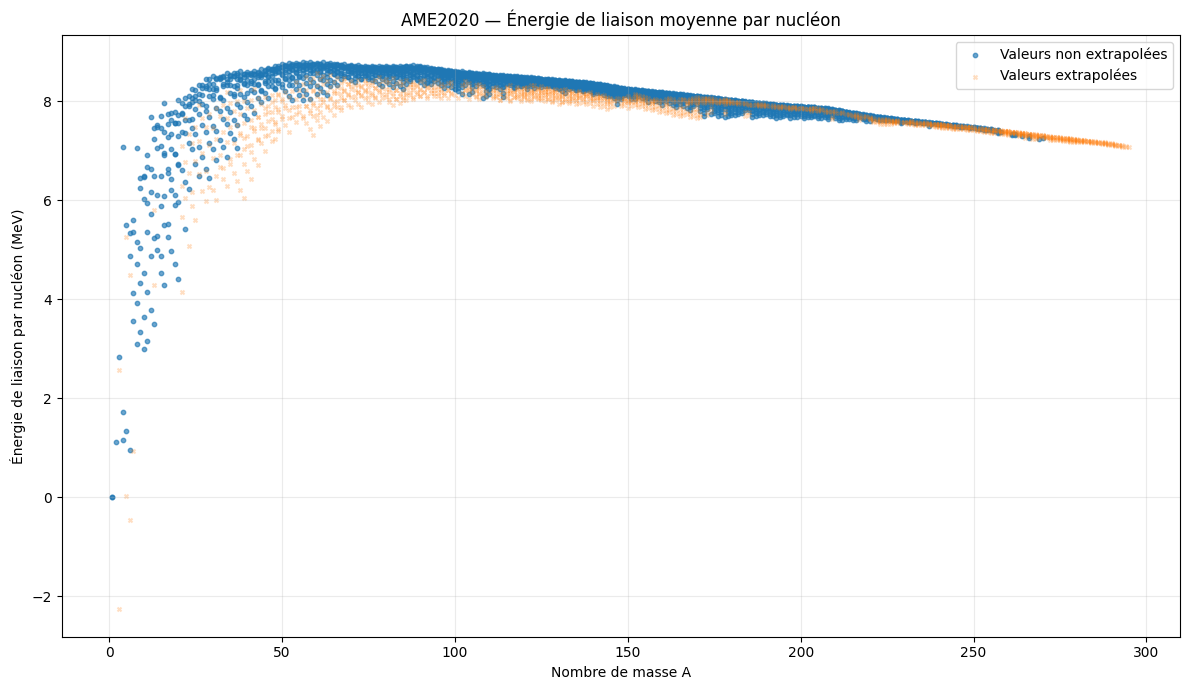

In [227]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plt.scatter(
    df_ame_mesure["A"],
    df_ame_mesure["energie_liaison_par_A_MeV_calculee"],
    s=10,
    alpha=0.65,
    label="Valeurs non extrapolées"
)

plt.scatter(
    df_ame_extrapole["A"],
    df_ame_extrapole["energie_liaison_par_A_MeV_calculee"],
    s=8,
    alpha=0.25,
    marker="x",
    label="Valeurs extrapolées"
)

plt.xlabel("Nombre de masse A")
plt.ylabel("Énergie de liaison par nucléon (MeV)")
plt.title(
    "AME2020 — Énergie de liaison moyenne par nucléon"
)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [228]:
colonnes_valides = [
    "energie_liaison_par_A_MeV_calculee",
    "A",
    "Z",
    "N",
]

masque_maximum = (
    df_ame2020[colonnes_valides]
    .notna()
    .all(axis=1)
    & ~df_ame2020["valeur_extrapolee"]
)

indice_maximum = df_ame2020.loc[
    masque_maximum,
    "energie_liaison_par_A_MeV_calculee"
].idxmax()

noyau_maximum = df_ame2020.loc[indice_maximum]

print("Noyau le plus lié par nucléon dans la table :")
print(f"Isotope : {noyau_maximum['isotope']}")
print(f"A       : {int(noyau_maximum['A'])}")
print(f"Z       : {int(noyau_maximum['Z'])}")
print(f"N       : {int(noyau_maximum['N'])}")
print(
    "E_b/A   :",
    f"{noyau_maximum['energie_liaison_par_A_MeV_calculee']:.6f}",
    "MeV/nucléon"
)

Noyau le plus lié par nucléon dans la table :
Isotope : Ni-62
A       : 62
Z       : 28
N       : 34
E_b/A   : 8.794556 MeV/nucléon


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [229]:
top_noyaux_lies = (
    df_ame2020.loc[
        masque_maximum,
        [
            "isotope",
            "A",
            "Z",
            "N",
            "energie_liaison_par_A_MeV_calculee",
            "incertitude_masse_u",
        ]
    ]
    .sort_values(
        "energie_liaison_par_A_MeV_calculee",
        ascending=False
    )
    .head(15)
    .reset_index(drop=True)
)

top_noyaux_lies

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,isotope,A,Z,N,energie_liaison_par_A_MeV_calculee,incertitude_masse_u
0,Ni-62,62,28,34,8.794556,4.550000e-07
1,Fe-58,58,26,32,8.792253,3.390000e-07
2,Fe-56,56,26,30,8.790356,2.870000e-07
3,Ni-60,60,28,32,8.780777,3.780000e-07
4,Cr-54,54,24,30,8.777967,1.420000e-07
5,Ni-64,64,28,36,8.777464,4.970000e-07
6,Cr-52,52,24,28,8.775995,1.200000e-07
7,Fe-57,57,26,31,8.770283,2.870000e-07
8,Co-59,59,27,32,8.768038,4.260000e-07
9,Ni-61,61,28,33,8.765028,3.810000e-07


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


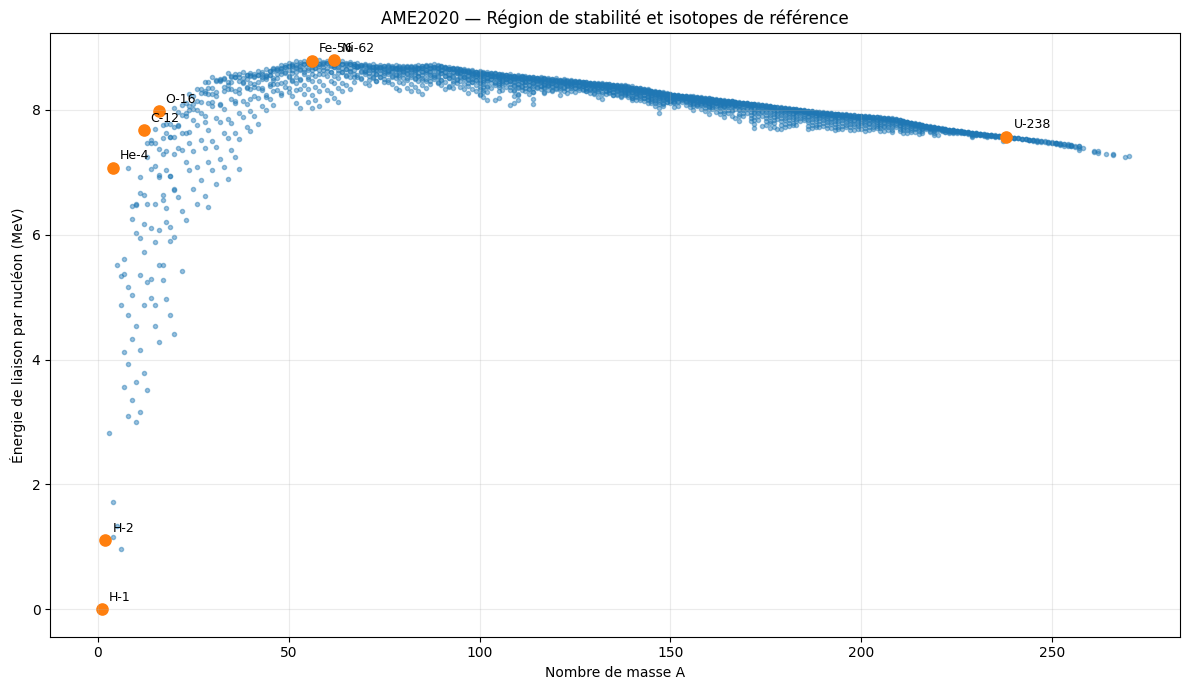

In [230]:
isotopes_repere = [
    "H-1",
    "H-2",
    "He-4",
    "C-12",
    "O-16",
    "Fe-56",
    "Ni-62",
    "U-238",
]

df_reperes = df_ame2020[
    df_ame2020["isotope"].isin(isotopes_repere)
].copy()

plt.figure(figsize=(12, 7))

plt.scatter(
    df_ame_mesure["A"],
    df_ame_mesure["energie_liaison_par_A_MeV_calculee"],
    s=9,
    alpha=0.45
)

plt.scatter(
    df_reperes["A"],
    df_reperes["energie_liaison_par_A_MeV_calculee"],
    s=65,
)

for _, ligne in df_reperes.iterrows():
    plt.annotate(
        ligne["isotope"],
        (
            ligne["A"],
            ligne["energie_liaison_par_A_MeV_calculee"]
        ),
        xytext=(5, 6),
        textcoords="offset points",
        fontsize=9
    )

plt.xlabel("Nombre de masse A")
plt.ylabel("Énergie de liaison par nucléon (MeV)")
plt.title(
    "AME2020 — Région de stabilité et isotopes de référence"
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 8. Bilan énergétique d'une réaction nucléaire

Pour une réaction nucléaire générale,

\[
a+b\rightarrow c+d+\cdots,
\]

l'énergie libérée ou absorbée est donnée par :

\[
Q=
\left(
\sum_i m_i^{\mathrm{réactifs}}
-
\sum_j m_j^{\mathrm{produits}}
\right)c^2.
\]

- Si \(Q>0\), la réaction est exoénergétique.
- Si \(Q<0\), la réaction nécessite un apport d'énergie.

Lorsque les masses atomiques sont utilisées, le nombre total d'électrons doit
être identique entre les réactifs et les produits, ou une correction explicite
doit être appliquée.

In [231]:
def masse_atomique_isotope_u(symbole: str, A: int) -> float:
    """
    Retourne la masse atomique AME2020 d'un isotope.
    """
    resultat = df_ame2020.loc[
        (df_ame2020["symbole"] == symbole)
        & (df_ame2020["A"] == A),
        "masse_atomique_u"
    ]

    if resultat.empty:
        raise KeyError(
            f"Isotope introuvable dans AME2020 : {symbole}-{A}"
        )

    masse = float(resultat.iloc[0])

    if not np.isfinite(masse):
        raise ValueError(
            f"Masse atomique indisponible pour {symbole}-{A}"
        )

    return masse

In [232]:
("He", 4, 2)

('He', 4, 2)

In [233]:
def bilan_Q_reaction_MeV(
    reactifs: list[tuple[str, int, int]],
    produits: list[tuple[str, int, int]]
) -> float:
    """
    Calcule le bilan énergétique Q d'une réaction à partir
    des masses atomiques AME2020.

    Chaque isotope est donné sous la forme :
    (symbole, A, coefficient)
    """
    masse_reactifs_u = 0.0
    masse_produits_u = 0.0

    for symbole, A, coefficient in reactifs:
        if coefficient <= 0:
            raise ValueError(
                "Les coefficients doivent être strictement positifs."
            )

        masse_reactifs_u += (
            coefficient
            * masse_atomique_isotope_u(symbole, A)
        )

    for symbole, A, coefficient in produits:
        if coefficient <= 0:
            raise ValueError(
                "Les coefficients doivent être strictement positifs."
            )

        masse_produits_u += (
            coefficient
            * masse_atomique_isotope_u(symbole, A)
        )

    defaut_masse_u = masse_reactifs_u - masse_produits_u

    return defaut_masse_u * u_c2_MeV

In [234]:
def bilan_Q_DT_MeV() -> float:
    masse_initiale_u = (
        masse_atomique_isotope_u("H", 2)
        + masse_atomique_isotope_u("H", 3)
    )

    masse_finale_u = (
        masse_atomique_isotope_u("He", 4)
        + masse_neutron_u
    )

    return (
        masse_initiale_u
        - masse_finale_u
    ) * u_c2_MeV


Q_DT = bilan_Q_DT_MeV()

print(
    "Réaction D + T → He-4 + n"
)
print(
    f"Q = {Q_DT:.6f} MeV"
)

Réaction D + T → He-4 + n
Q = 17.589300 MeV


In [235]:
def bilan_Q_DT_MeV() -> float:
    masse_initiale_u = (
        masse_atomique_isotope_u("H", 2)
        + masse_atomique_isotope_u("H", 3)
    )

    masse_finale_u = (
        masse_atomique_isotope_u("He", 4)
        + masse_neutron_u
    )

    return (
        masse_initiale_u
        - masse_finale_u
    ) * u_c2_MeV


Q_DT = bilan_Q_DT_MeV()

print(
    "Réaction D + T → He-4 + n"
)
print(
    f"Q = {Q_DT:.6f} MeV"
)

Réaction D + T → He-4 + n
Q = 17.589300 MeV


In [236]:
def verifier_conservation_reaction(
    reactifs: list[tuple[str, int, int]],
    produits: list[tuple[str, int, int]]
) -> tuple[bool, dict]:
    """
    Vérifie la conservation du nombre de masse A
    et du nombre de charge Z.
    """
    table_Z = (
        df_ame2020[
            ["symbole", "Z"]
        ]
        .drop_duplicates()
        .set_index("symbole")["Z"]
        .to_dict()
    )

    A_reactifs = sum(
        A * coefficient
        for symbole, A, coefficient in reactifs
    )

    Z_reactifs = sum(
        table_Z[symbole] * coefficient
        for symbole, A, coefficient in reactifs
    )

    A_produits = sum(
        A * coefficient
        for symbole, A, coefficient in produits
    )

    Z_produits = sum(
        table_Z[symbole] * coefficient
        for symbole, A, coefficient in produits
    )

    details = {
        "A_reactifs": A_reactifs,
        "A_produits": A_produits,
        "Z_reactifs": Z_reactifs,
        "Z_produits": Z_produits,
    }

    conservation = (
        A_reactifs == A_produits
        and Z_reactifs == Z_produits
    )

    return conservation, details

In [237]:
masse_He4_u = masse_atomique_isotope_u("He", 4)

# Pour utiliser la masse du noyau alpha, on retire les deux électrons.
masse_alpha_kg = masse_atomique_vers_nucleaire_kg(
    masse_atomique_u=masse_He4_u,
    Z=2
)

masse_alpha_u = masse_alpha_kg / m_u

energie_neutron_MeV = (
    Q_DT
    * masse_alpha_u
    / (masse_neutron_u + masse_alpha_u)
)

energie_alpha_MeV = (
    Q_DT
    * masse_neutron_u
    / (masse_neutron_u + masse_alpha_u)
)

print(f"Énergie du neutron : {energie_neutron_MeV:.6f} MeV")
print(f"Énergie de He-4    : {energie_alpha_MeV:.6f} MeV")
print(
    "Somme             :",
    f"{energie_neutron_MeV + energie_alpha_MeV:.6f} MeV"
)

Énergie du neutron : 14.048161 MeV
Énergie de He-4    : 3.541139 MeV
Somme             : 17.589300 MeV


In [238]:
A_initial = 2 + 3
Z_initial = 1 + 1

A_final = 4 + 1
Z_final = 2 + 0

assert A_initial == A_final
assert Z_initial == Z_final
assert Q_DT > 0

print("✅ Nombre de masse A conservé.")
print("✅ Charge nucléaire Z conservée.")
print("✅ Réaction exoénergétique.")

✅ Nombre de masse A conservé.
✅ Charge nucléaire Z conservée.
✅ Réaction exoénergétique.


In [239]:
Q_DT_J = Q_DT * 1e6 * e

print(f"Énergie par réaction : {Q_DT_J:.12e} J")

Énergie par réaction : 2.818116505846e-12 J


In [240]:
energie_molaire_DT_J = Q_DT_J * N_A

print(
    "Énergie pour une mole de réactions :",
    f"{energie_molaire_DT_J:.6e} J"
)

print(
    "Énergie pour une mole de réactions :",
    f"{energie_molaire_DT_J / 1e12:.6f} TJ"
)

Énergie pour une mole de réactions : 1.697109e+12 J
Énergie pour une mole de réactions : 1.697109 TJ


In [241]:
Q_DT_J = Q_DT * 1e6 * e

print(f"Énergie par réaction : {Q_DT_J:.12e} J")

Énergie par réaction : 2.818116505846e-12 J


## 9. Représentation générale des particules nucléaires

Les réactions nucléaires peuvent contenir des noyaux, des atomes neutres et des
particules libres.

Chaque particule sera caractérisée par :

- une masse au repos ;
- un nombre baryonique \(A\) ;
- une charge électrique \(Z\) exprimée en unités de \(e\) ;
- un nombre leptonique \(L\).

Cette représentation permettra de vérifier automatiquement plusieurs lois de
conservation avant de calculer le bilan énergétique \(Q\).

In [242]:
masse_electron_u = m_e / m_u
masse_proton_u = m_p / m_u

PARTICULES_LIBRES = {
    "n": {
        "nom": "neutron",
        "masse_u": masse_neutron_u,
        "A": 1,
        "Z": 0,
        "L": 0,
    },
    "p": {
        "nom": "proton",
        "masse_u": masse_proton_u,
        "A": 1,
        "Z": 1,
        "L": 0,
    },
    "e-": {
        "nom": "électron",
        "masse_u": masse_electron_u,
        "A": 0,
        "Z": -1,
        "L": 1,
    },
    "e+": {
        "nom": "positron",
        "masse_u": masse_electron_u,
        "A": 0,
        "Z": 1,
        "L": -1,
    },
    "nu_e": {
        "nom": "neutrino électronique",
        "masse_u": 0.0,
        "A": 0,
        "Z": 0,
        "L": 1,
    },
    "anti_nu_e": {
        "nom": "antineutrino électronique",
        "masse_u": 0.0,
        "A": 0,
        "Z": 0,
        "L": -1,
    },
}

for cle, particule in PARTICULES_LIBRES.items():
    print(
        f"{cle:10s} "
        f"m={particule['masse_u']:.12e} u, "
        f"A={particule['A']}, "
        f"Z={particule['Z']}, "
        f"L={particule['L']}"
    )

n          m=1.008664916056e+00 u, A=1, Z=0, L=0
p          m=1.007276466574e+00 u, A=1, Z=1, L=0
e-         m=5.485799090427e-04 u, A=0, Z=-1, L=1
e+         m=5.485799090427e-04 u, A=0, Z=1, L=-1
nu_e       m=0.000000000000e+00 u, A=0, Z=0, L=1
anti_nu_e  m=0.000000000000e+00 u, A=0, Z=0, L=-1


In [243]:
("isotope", "He", 4, 1)

('isotope', 'He', 4, 1)

In [244]:
("particule", "n", 1)

('particule', 'n', 1)

In [245]:
def proprietes_espece(espece: tuple) -> dict:
    """
    Retourne les propriétés d'un isotope ou d'une particule libre.

    Formats acceptés
    ----------------
    ("isotope", symbole, A, coefficient)
    ("particule", identifiant, coefficient)
    """
    if not isinstance(espece, tuple):
        raise TypeError("Une espèce doit être représentée par un tuple.")

    type_espece = espece[0]

    if type_espece == "isotope":
        if len(espece) != 4:
            raise ValueError(
                "Format isotope attendu : "
                "('isotope', symbole, A, coefficient)"
            )

        _, symbole, A, coefficient = espece

        ligne = df_ame2020.loc[
            (df_ame2020["symbole"] == symbole)
            & (df_ame2020["A"] == A)
        ]

        if ligne.empty:
            raise KeyError(f"Isotope introuvable : {symbole}-{A}")

        ligne = ligne.iloc[0]

        return {
            "nom": f"{symbole}-{A}",
            "masse_u": float(ligne["masse_atomique_u"]),
            "A": int(ligne["A"]),
            "Z": int(ligne["Z"]),
            "L": 0,
            "coefficient": int(coefficient),
        }

    if type_espece == "particule":
        if len(espece) != 3:
            raise ValueError(
                "Format particule attendu : "
                "('particule', identifiant, coefficient)"
            )

        _, identifiant, coefficient = espece

        if identifiant not in PARTICULES_LIBRES:
            raise KeyError(
                f"Particule inconnue : {identifiant}"
            )

        particule = PARTICULES_LIBRES[identifiant]

        return {
            **particule,
            "coefficient": int(coefficient),
        }

    raise ValueError(
        "Le premier élément doit être 'isotope' ou 'particule'."
    )

In [246]:
def totaux_reaction(especes: list[tuple]) -> dict:
    """
    Calcule la masse totale et les nombres quantiques totaux.
    """
    totaux = {
        "masse_u": 0.0,
        "A": 0,
        "Z": 0,
        "L": 0,
    }

    for espece in especes:
        proprietes = proprietes_espece(espece)
        coefficient = proprietes["coefficient"]

        if coefficient <= 0:
            raise ValueError(
                "Chaque coefficient doit être strictement positif."
            )

        totaux["masse_u"] += (
            coefficient * proprietes["masse_u"]
        )
        totaux["A"] += coefficient * proprietes["A"]
        totaux["Z"] += coefficient * proprietes["Z"]
        totaux["L"] += coefficient * proprietes["L"]

    return totaux


def analyser_reaction(
    reactifs: list[tuple],
    produits: list[tuple]
) -> dict:
    """
    Vérifie les conservations et calcule le bilan énergétique Q.
    """
    total_reactifs = totaux_reaction(reactifs)
    total_produits = totaux_reaction(produits)

    Q_MeV = (
        total_reactifs["masse_u"]
        - total_produits["masse_u"]
    ) * u_c2_MeV

    return {
        "Q_MeV": Q_MeV,
        "exoenergetique": Q_MeV > 0,
        "conservation_A":
            total_reactifs["A"] == total_produits["A"],
        "conservation_Z":
            total_reactifs["Z"] == total_produits["Z"],
        "conservation_L":
            total_reactifs["L"] == total_produits["L"],
        "reactifs": total_reactifs,
        "produits": total_produits,
    }

In [247]:
reaction_DT = analyser_reaction(
    reactifs=[
        ("isotope", "H", 2, 1),
        ("isotope", "H", 3, 1),
    ],
    produits=[
        ("isotope", "He", 4, 1),
        ("particule", "n", 1),
    ],
)

for cle, valeur in reaction_DT.items():
    print(f"{cle} : {valeur}")

Q_MeV : 17.58929974412325
exoenergetique : True
conservation_A : True
conservation_Z : True
conservation_L : True
reactifs : {'masse_u': 5.030151059164, 'A': 5, 'Z': 2, 'L': 0}
produits : {'masse_u': 5.01126817018606, 'A': 5, 'Z': 2, 'L': 0}


In [248]:
assert reaction_DT["conservation_A"]
assert reaction_DT["conservation_Z"]
assert reaction_DT["conservation_L"]
assert np.isclose(
    reaction_DT["Q_MeV"],
    Q_DT,
    atol=1e-6
)

print("✅ Représentation générale validée avec la réaction D–T.")

✅ Représentation générale validée avec la réaction D–T.


In [249]:
reaction_pp1 = analyser_reaction(
    reactifs=[
        ("isotope", "H", 1, 2),
    ],
    produits=[
        ("isotope", "H", 2, 1),
        ("particule", "e+", 1),
        ("particule", "nu_e", 1),
    ],
)

for cle, valeur in reaction_pp1.items():
    print(f"{cle} : {valeur}")

Q_MeV : 0.9312202844664377
exoenergetique : True
conservation_A : True
conservation_Z : True
conservation_L : True
reactifs : {'masse_u': 2.015650063796, 'A': 2, 'Z': 2, 'L': 0}
produits : {'masse_u': 2.014650357753043, 'A': 2, 'Z': 2, 'L': 0}


In [250]:
assert reaction_pp1["conservation_A"]
assert reaction_pp1["conservation_Z"]
assert reaction_pp1["conservation_L"]
assert reaction_pp1["Q_MeV"] > 0

print("✅ Réaction p-p initiale validée.")
print(f"Q disponible = {reaction_pp1['Q_MeV']:.6f} MeV")

✅ Réaction p-p initiale validée.
Q disponible = 0.931220 MeV


In [251]:
masse_D_atomique_u = masse_atomique_isotope_u("H", 2)

masse_D_noyau_kg = masse_atomique_vers_nucleaire_kg(
    masse_atomique_u=masse_D_atomique_u,
    Z=1,
    energie_liaison_electronique_eV=13.6
)

masse_deuteron_u = masse_D_noyau_kg / m_u

print(f"Masse atomique H-2 : {masse_D_atomique_u:.12f} u")
print(f"Masse du deutéron  : {masse_deuteron_u:.12f} u")

Masse atomique H-2 : 2.014101777844 u
Masse du deutéron  : 2.013553212535 u


In [252]:
Q_pp_nucleaire_MeV = (
    2 * masse_proton_u
    - masse_deuteron_u
    - masse_electron_u
) * u_c2_MeV

print("p + p → d + e+ + νe")
print(f"Q nucléaire = {Q_pp_nucleaire_MeV:.6f} MeV")

p + p → d + e+ + νe
Q nucléaire = 0.420235 MeV


In [253]:
Q_annihilation_MeV = (
    2 * masse_electron_u * u_c2_MeV
)

Q_pp_total_MeV = (
    Q_pp_nucleaire_MeV
    + Q_annihilation_MeV
)

print(f"Énergie d'annihilation = {Q_annihilation_MeV:.6f} MeV")
print(f"Énergie totale         = {Q_pp_total_MeV:.6f} MeV")

Énergie d'annihilation = 1.021998 MeV
Énergie totale         = 1.442233 MeV


In [254]:
assert Q_pp_nucleaire_MeV > 0

assert np.isclose(
    Q_pp_nucleaire_MeV,
    0.420,
    atol=0.002
)

assert np.isclose(
    Q_annihilation_MeV,
    1.022,
    atol=0.002
)

assert np.isclose(
    Q_pp_total_MeV,
    1.442,
    atol=0.002
)

print("✅ Réaction p + p → d + e+ + νe validée.")
print("✅ Annihilation e+ + e− → 2γ validée.")
print("✅ Énergie totale de la première étape p-p validée.")

✅ Réaction p + p → d + e+ + νe validée.
✅ Annihilation e+ + e− → 2γ validée.
✅ Énergie totale de la première étape p-p validée.


In [255]:
E_nu_max_pp_MeV = Q_pp_nucleaire_MeV

print(
    "Énergie maximale cinématiquement disponible "
    f"pour le neutrino pp : {E_nu_max_pp_MeV:.6f} MeV"
)

Énergie maximale cinématiquement disponible pour le neutrino pp : 0.420235 MeV


In [256]:
masse_He3_atomique_u = masse_atomique_isotope_u("He", 3)

masse_He3_noyau_kg = masse_atomique_vers_nucleaire_kg(
    masse_atomique_u=masse_He3_atomique_u,
    Z=2
)

masse_He3_noyau_u = masse_He3_noyau_kg / m_u

print(f"Masse atomique He-3 : {masse_He3_atomique_u:.12f} u")
print(f"Masse nucléaire He-3: {masse_He3_noyau_u:.12f} u")

Masse atomique He-3 : 3.016029321970 u
Masse nucléaire He-3: 3.014932162152 u


In [257]:
Q_dp_He3_MeV = (
    masse_deuteron_u
    + masse_proton_u
    - masse_He3_noyau_u
) * u_c2_MeV

print("d + p → He-3 + γ")
print(f"Q = {Q_dp_He3_MeV:.6f} MeV")

d + p → He-3 + γ
Q = 5.493502 MeV


In [258]:
assert Q_dp_He3_MeV > 0

assert np.isclose(
    Q_dp_He3_MeV,
    5.493,
    atol=0.003
)

print("✅ Réaction d + p → He-3 + γ validée.")

✅ Réaction d + p → He-3 + γ validée.


In [259]:
Q_He3_He3_MeV = (
    2 * masse_He3_noyau_u
    - masse_alpha_u
    - 2 * masse_proton_u
) * u_c2_MeV

print("He-3 + He-3 → He-4 + 2p")
print(f"Q = {Q_He3_He3_MeV:.6f} MeV")

He-3 + He-3 → He-4 + 2p
Q = 12.859553 MeV


In [260]:
A_initial_ppI = 3 + 3
Z_initial_ppI = 2 + 2

A_final_ppI = 4 + 1 + 1
Z_final_ppI = 2 + 1 + 1

assert A_initial_ppI == A_final_ppI
assert Z_initial_ppI == Z_final_ppI
assert Q_He3_He3_MeV > 0

assert np.isclose(
    Q_He3_He3_MeV,
    12.860,
    atol=0.005
)

print("✅ Nombre baryonique conservé.")
print("✅ Charge électrique conservée.")
print("✅ Réaction He-3 + He-3 → He-4 + 2p validée.")

✅ Nombre baryonique conservé.
✅ Charge électrique conservée.
✅ Réaction He-3 + He-3 → He-4 + 2p validée.


In [261]:
Q_ppI_nucleaire_MeV = (
    2 * Q_pp_nucleaire_MeV
    + 2 * Q_dp_He3_MeV
    + Q_He3_He3_MeV
)

Q_ppI_annihilation_MeV = (
    2 * Q_annihilation_MeV
)

Q_ppI_total_MeV = (
    Q_ppI_nucleaire_MeV
    + Q_ppI_annihilation_MeV
)

print(
    f"Énergie nucléaire pp-I     : "
    f"{Q_ppI_nucleaire_MeV:.6f} MeV"
)

print(
    f"Énergie d'annihilation     : "
    f"{Q_ppI_annihilation_MeV:.6f} MeV"
)

print(
    f"Énergie totale produite    : "
    f"{Q_ppI_total_MeV:.6f} MeV"
)

Énergie nucléaire pp-I     : 24.687027 MeV
Énergie d'annihilation     : 2.043996 MeV
Énergie totale produite    : 26.731023 MeV


In [262]:
E_nu_pp_moyen_MeV = 0.265

E_nu_ppI_total_MeV = (
    2 * E_nu_pp_moyen_MeV
)

Q_ppI_depose_MeV = (
    Q_ppI_total_MeV
    - E_nu_ppI_total_MeV
)

fraction_neutrinos_ppI = (
    E_nu_ppI_total_MeV
    / Q_ppI_total_MeV
)

fraction_deposee_ppI = (
    Q_ppI_depose_MeV
    / Q_ppI_total_MeV
)

print(
    f"Énergie moyenne des deux neutrinos : "
    f"{E_nu_ppI_total_MeV:.6f} MeV"
)

print(
    f"Énergie déposée dans l'étoile      : "
    f"{Q_ppI_depose_MeV:.6f} MeV"
)

print(
    f"Fraction emportée par les neutrinos : "
    f"{100 * fraction_neutrinos_ppI:.3f} %"
)

print(
    f"Fraction déposée dans l'étoile      : "
    f"{100 * fraction_deposee_ppI:.3f} %"
)

Énergie moyenne des deux neutrinos : 0.530000 MeV
Énergie déposée dans l'étoile      : 26.201023 MeV
Fraction emportée par les neutrinos : 1.983 %
Fraction déposée dans l'étoile      : 98.017 %


In [263]:
assert E_nu_ppI_total_MeV > 0
assert Q_ppI_depose_MeV < Q_ppI_total_MeV
assert Q_ppI_depose_MeV > 0

assert np.isclose(
    Q_ppI_depose_MeV,
    26.20,
    atol=0.05
)

print("✅ Pertes énergétiques par neutrinos prises en compte.")
print("✅ Énergie effectivement déposée dans l'étoile calculée.")

✅ Pertes énergétiques par neutrinos prises en compte.
✅ Énergie effectivement déposée dans l'étoile calculée.


### Bilan énergétique moyen de la branche pp-I

Le bilan net de la branche pp-I est :

\[
4p + 2e^-
\rightarrow
{}^{4}\mathrm{He}
+
2\nu_e
+
26.731023\ \mathrm{MeV}.
\]

L'énergie totale libérée se répartit entre :

- l'énergie déposée dans le plasma stellaire ;
- l'énergie emportée par les deux neutrinos électroniques.

En utilisant une énergie moyenne de \(0.265\ \mathrm{MeV}\) par neutrino pp :

\[
E_{\nu,\mathrm{total}}
=
0.530000\ \mathrm{MeV},
\]

\[
Q_{\mathrm{déposé}}
=
26.201023\ \mathrm{MeV}.
\]

Ainsi, environ \(1.983\%\) de l'énergie est emportée par les neutrinos et
\(98.017\%\) est déposée dans l'étoile.

L'énergie des neutrinos n'est pas fixe : elle suit un spectre continu.
La valeur calculée ici représente donc un bilan énergétique moyen.

# Partie I.2 — Chaîne proton-proton complète

## Objectifs

Cette partie étend l'étude de la branche pp-I vers l'ensemble de la chaîne proton-proton.

Les objectifs sont :

1. réutiliser les masses nucléaires validées dans la Partie I.1 ;
2. reconstruire les branches pp-I, pp-II et pp-III ;
3. calculer les bilans énergétiques de chaque réaction ;
4. vérifier les conservations de \(A\), de \(Z\) et du nombre leptonique ;
5. séparer l'énergie totale libérée de l'énergie emportée par les neutrinos ;
6. comparer les différentes branches ;
7. étudier qualitativement puis quantitativement leur dépendance à la température.

La chaîne proton-proton transforme globalement quatre protons en un noyau d'hélium-4 :

\[
4p + 2e^-
\rightarrow
{}^{4}\mathrm{He}
+
2\nu_e
+
\text{énergie}.
\]

Les trois branches principales diffèrent par leurs noyaux intermédiaires et par les neutrinos produits :

- pp-I ;
- pp-II ;
- pp-III.

In [264]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("✅ Dépendances importées.")

✅ Dépendances importées.


In [265]:
DOSSIER_DEPOT = Path("/content/Univers")
RACINE_DEPOT = DOSSIER_DEPOT / "gvh_dynamic"

DOSSIER_NUCLEAR = RACINE_DEPOT / "Data" / "Nuclear"
DOSSIER_AME2020 = DOSSIER_NUCLEAR / "AME2020"
DOSSIER_CODATA = DOSSIER_NUCLEAR / "CODATA"

print("Racine du dépôt :", RACINE_DEPOT)
print("AME2020          :", DOSSIER_AME2020)
print("CODATA           :", DOSSIER_CODATA)

Racine du dépôt : /content/Univers/gvh_dynamic
AME2020          : /content/Univers/gvh_dynamic/Data/Nuclear/AME2020
CODATA           : /content/Univers/gvh_dynamic/Data/Nuclear/CODATA


In [266]:
assert RACINE_DEPOT.exists(), (
    f"Le dépôt est introuvable : {RACINE_DEPOT}"
)

assert DOSSIER_AME2020.exists(), (
    f"Le dossier AME2020 est introuvable : {DOSSIER_AME2020}"
)

assert DOSSIER_CODATA.exists(), (
    f"Le dossier CODATA est introuvable : {DOSSIER_CODATA}"
)

print("✅ Structure du dépôt validée.")

✅ Structure du dépôt validée.


## Réutilisation des outils validés dans la Partie I.1

Cette partie ne redéfinit pas la physique nucléaire fondamentale.

Elle réutilise les outils déjà validés pour :

- lire AME2020 ;
- charger les constantes CODATA ;
- convertir les masses atomiques en masses nucléaires ;
- récupérer les propriétés des isotopes ;
- calculer les bilans énergétiques \(Q\) ;
- vérifier les lois de conservation.

Afin d'éviter la duplication de code, ces fonctions devront progressivement être déplacées dans un module Python commun.

In [267]:
# Option provisoire :
# recopier uniquement les fonctions indispensables depuis I.1

# Option recommandée à terme :
# from src.nuclear_utils import ...

In [268]:
branches_pp = pd.DataFrame(
    [
        {
            "branche": "pp-I",
            "reaction_finale": "He-3 + He-3 → He-4 + 2p",
            "neutrinos_principaux": "pp",
            "etat": "validée"
        },
        {
            "branche": "pp-II",
            "reaction_finale": "Li-7 + p → 2 He-4",
            "neutrinos_principaux": "pp, Be-7",
            "etat": "à calculer"
        },
        {
            "branche": "pp-III",
            "reaction_finale": "Be-8 → 2 He-4",
            "neutrinos_principaux": "pp, B-8",
            "etat": "à calculer"
        }
    ]
)

branches_pp

,branche,reaction_finale,neutrinos_principaux,etat
0,pp-I,He-3 + He-3 → He-4 + 2p,pp,validée
1,pp-II,Li-7 + p → 2 He-4,"pp, Be-7",à calculer
2,pp-III,Be-8 → 2 He-4,"pp, B-8",à calculer


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [269]:
assert len(branches_pp) == 3
assert set(branches_pp["branche"]) == {"pp-I", "pp-II", "pp-III"}

print("✅ Architecture des trois branches créée.")

✅ Architecture des trois branches créée.


In [270]:
isotopes_pp = [
    ("H", 1),
    ("H", 2),
    ("He", 3),
    ("He", 4),
    ("Be", 7),
    ("Li", 7),
    ("B", 8),
    ("Be", 8),
]

isotopes_pp

[('H', 1),
 ('H', 2),
 ('He', 3),
 ('He', 4),
 ('Be', 7),
 ('Li', 7),
 ('B', 8),
 ('Be', 8)]

In [271]:
assert len(isotopes_pp) == 8
assert len(set(isotopes_pp)) == 8

print("✅ Liste des isotopes nécessaires créée.")

✅ Liste des isotopes nécessaires créée.


In [272]:
fonctions_requises = [
    "masse_atomique_vers_nucleaire_kg",
    "u_vers_kg",
]

for nom in fonctions_requises:
    print(
        f"{nom:<40}",
        "✅ disponible" if nom in globals() else "❌ absente"
    )

masse_atomique_vers_nucleaire_kg         ✅ disponible
u_vers_kg                                ✅ disponible


In [273]:
dataframes_disponibles = {
    nom: objet.shape
    for nom, objet in globals().items()
    if isinstance(objet, pd.DataFrame)
}

dataframes_disponibles

{'__': (6, 9),
 '___': (6, 8),
 'df_codata': (355, 7),
 '_11': (10, 6),
 '_12': (10, 4),
 '_13': (10, 7),
 'df_constantes_essentielles': (10, 5),
 '_14': (0, 5),
 '_15': (10, 7),
 '_16': (10, 5),
 'df_ame2020': (3558, 21),
 '_31': (15, 16),
 'df_controle_ame': (6, 8),
 '_33': (6, 8),
 '_39': (6, 9),
 'df_ame_mesure': (2328, 21),
 'df_ame_extrapole': (1230, 21),
 'top_noyaux_lies': (15, 6),
 '_44': (15, 6),
 'df_reperes': (8, 21),
 'branches_pp': (3, 4),
 '_83': (3, 4),
 'ame2020_pp': (3558, 21),
 'table_isotopes_pp': (8, 7),
 '_98': (8, 7),
 '_103': (8, 7),
 'comparaison_branches_pp': (3, 7),
 '_141': (3, 7),
 'proportions_branches_solaires': (3, 4),
 '_150': (3, 4),
 'bilan_pp_solaire': (3, 12),
 '_152': (3, 12),
 '_153': (3, 4),
 '_155': (3, 3),
 '_157': (3, 7),
 'production_solaire_pp': (10, 3),
 'bilan_masse_energie_pp': (9, 3),
 'df_controle': (9, 3),
 '_196': (10, 6),
 '_197': (10, 4),
 '_198': (10, 7),
 '_199': (0, 5),
 '_200': (10, 7),
 '_201': (10, 5),
 '_216': (15, 16),
 '_21

In [274]:
def trouver_dataframe_ame2020():
    candidats = []

    for nom, objet in globals().items():
        if not isinstance(objet, pd.DataFrame):
            continue

        colonnes = set(objet.columns)

        conditions = [
            {"A", "Z", "symbole"}.issubset(colonnes),
            len(objet) >= 3000,
        ]

        if all(conditions):
            candidats.append((nom, objet))

    if len(candidats) == 0:
        raise RuntimeError(
            "Aucun DataFrame AME2020 compatible n'a été trouvé."
        )

    if len(candidats) > 1:
        print("Plusieurs candidats détectés :")
        for nom, objet in candidats:
            print(f"- {nom}: {objet.shape}")

    nom, dataframe = candidats[0]

    print(f"✅ DataFrame AME2020 sélectionné : {nom}")
    print(f"Dimensions : {dataframe.shape}")

    return dataframe.copy()


ame2020_pp = trouver_dataframe_ame2020()

Plusieurs candidats détectés :
- df_ame2020: (3558, 21)
- ame2020_pp: (3558, 21)
✅ DataFrame AME2020 sélectionné : df_ame2020
Dimensions : (3558, 21)


In [275]:
assert len(ame2020_pp) >= 3500
assert {"A", "Z", "symbole"}.issubset(ame2020_pp.columns)

print("✅ Base AME2020 prête pour la chaîne proton-proton.")

✅ Base AME2020 prête pour la chaîne proton-proton.


In [276]:
print("Colonnes disponibles :")

for colonne in ame2020_pp.columns:
    print("-", colonne)

Colonnes disponibles :
- ligne_source
- N
- Z
- A
- symbole
- isotope
- exces_masse_keV
- incertitude_exces_masse_keV
- energie_liaison_par_A_keV
- incertitude_liaison_par_A_keV
- type_beta
- energie_beta_keV
- incertitude_beta_keV
- masse_atomique_u
- incertitude_masse_u
- valeur_extrapolee
- defaut_masse_u_calcule
- energie_liaison_MeV_calculee
- energie_liaison_par_A_MeV_calculee
- energie_liaison_par_A_MeV_AME
- ecart_liaison_par_A_keV


In [277]:
colonnes_masse = [
    colonne
    for colonne in ame2020_pp.columns
    if "mass" in str(colonne).lower()
    or "masse" in str(colonne).lower()
]

colonnes_masse

['exces_masse_keV',
 'incertitude_exces_masse_keV',
 'masse_atomique_u',
 'incertitude_masse_u',
 'defaut_masse_u_calcule']

In [278]:
COLONNE_MASSE_ATOMIQUE = "atomic_mass_u"

In [279]:
COLONNE_MASSE_ATOMIQUE = "masse_atomique_u"

assert COLONNE_MASSE_ATOMIQUE in ame2020_pp.columns

print(
    "✅ Colonne de masse atomique sélectionnée :",
    COLONNE_MASSE_ATOMIQUE
)

✅ Colonne de masse atomique sélectionnée : masse_atomique_u


In [280]:
def extraire_isotope_ame2020(
    dataframe,
    symbole,
    A,
):
    masque = (
        dataframe["symbole"].astype(str).str.strip().str.capitalize()
        == symbole.capitalize()
    ) & (
        dataframe["A"].astype(int) == int(A)
    )

    resultat = dataframe.loc[masque].copy()

    if len(resultat) == 0:
        raise KeyError(
            f"Isotope introuvable dans AME2020 : {symbole}-{A}"
        )

    if len(resultat) > 1:
        raise ValueError(
            f"Plusieurs entrées trouvées pour {symbole}-{A}"
        )

    return resultat.iloc[0]

In [281]:
test_He3 = extraire_isotope_ame2020(
    ame2020_pp,
    "He",
    3,
)

test_He3

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,4
ligne_source,41
N,1
Z,2
A,3
symbole,He
isotope,He-3
exces_masse_keV,14931.21888
incertitude_exces_masse_keV,0.00006
energie_liaison_par_A_keV,2572.68044
incertitude_liaison_par_A_keV,0.00015


In [282]:
assert int(test_He3["A"]) == 3
assert int(test_He3["Z"]) == 2

print("✅ Extraction de He-3 validée.")

✅ Extraction de He-3 validée.


In [283]:
lignes_isotopes_pp = []

for symbole, A in isotopes_pp:
    ligne = extraire_isotope_ame2020(
        ame2020_pp,
        symbole,
        A,
    )

    Z = int(ligne["Z"])
    N = int(ligne["N"])

    masse_atomique_u = float(
        ligne[COLONNE_MASSE_ATOMIQUE]
    )

    lignes_isotopes_pp.append(
        {
            "isotope": f"{symbole}-{A}",
            "symbole": symbole,
            "A": int(A),
            "Z": Z,
            "N": N,
            "masse_atomique_u": masse_atomique_u,
        }
    )

table_isotopes_pp = pd.DataFrame(
    lignes_isotopes_pp
)

table_isotopes_pp

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,isotope,symbole,A,Z,N,masse_atomique_u
0,H-1,H,1,1,0,1.007825
1,H-2,H,2,1,1,2.014102
2,He-3,He,3,2,1,3.016029
3,He-4,He,4,2,2,4.002603
4,Be-7,Be,7,4,3,7.016929
5,Li-7,Li,7,3,4,7.016003
6,B-8,B,8,5,3,8.024607
7,Be-8,Be,8,4,4,8.005305


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [284]:
assert len(table_isotopes_pp) == 8

assert table_isotopes_pp["isotope"].is_unique

assert np.all(
    table_isotopes_pp["A"]
    ==
    table_isotopes_pp["Z"]
    +
    table_isotopes_pp["N"]
)

assert table_isotopes_pp["masse_atomique_u"].notna().all()

print("✅ Table atomique des isotopes pp créée.")

✅ Table atomique des isotopes pp créée.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [285]:
fonctions_requises = [
    "masse_atomique_vers_nucleaire_kg",
    "u_vers_kg",
]

for nom in fonctions_requises:
    disponible = nom in globals()

    print(
        f"{nom:<40}",
        "✅ disponible" if disponible else "❌ absente"
    )

masse_atomique_vers_nucleaire_kg         ✅ disponible
u_vers_kg                                ✅ disponible


In [286]:
masse_electron_u = m_e / m_u

print(
    f"Masse de l'électron : "
    f"{masse_electron_u:.12f} u"
)

Masse de l'électron : 0.000548579909 u


In [287]:
def masse_atomique_vers_nucleaire_u(
    masse_atomique_u,
    Z,
):
    return (
        float(masse_atomique_u)
        -
        int(Z) * masse_electron_u
    )

In [288]:
table_isotopes_pp["masse_nucleaire_u"] = [
    masse_atomique_vers_nucleaire_u(
        masse_atomique_u,
        Z,
    )
    for masse_atomique_u, Z
    in zip(
        table_isotopes_pp["masse_atomique_u"],
        table_isotopes_pp["Z"],
    )
]

table_isotopes_pp

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,isotope,symbole,A,Z,N,masse_atomique_u,masse_nucleaire_u
0,H-1,H,1,1,0,1.007825,1.007276
1,H-2,H,2,1,1,2.014102,2.013553
2,He-3,He,3,2,1,3.016029,3.014932
3,He-4,He,4,2,2,4.002603,4.001506
4,Be-7,Be,7,4,3,7.016929,7.014734
5,Li-7,Li,7,3,4,7.016003,7.014358
6,B-8,B,8,5,3,8.024607,8.021864
7,Be-8,Be,8,4,4,8.005305,8.003111


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [289]:
assert table_isotopes_pp[
    "masse_nucleaire_u"
].notna().all()

assert np.all(
    table_isotopes_pp["masse_nucleaire_u"]
    >
    0
)

assert np.all(
    table_isotopes_pp["masse_nucleaire_u"]
    <
    table_isotopes_pp["masse_atomique_u"]
)

print("✅ Masses nucléaires calculées.")
print("✅ Toutes les masses nucléaires sont positives.")
print("✅ Toutes sont inférieures aux masses atomiques.")

✅ Masses nucléaires calculées.
✅ Toutes les masses nucléaires sont positives.
✅ Toutes sont inférieures aux masses atomiques.


In [290]:
He3_reference = table_isotopes_pp.loc[
    table_isotopes_pp["isotope"] == "He-3"
].iloc[0]

print(
    f"Masse atomique He-3 : "
    f"{He3_reference['masse_atomique_u']:.12f} u"
)

print(
    f"Masse nucléaire He-3: "
    f"{He3_reference['masse_nucleaire_u']:.12f} u"
)

Masse atomique He-3 : 3.016029321970 u
Masse nucléaire He-3: 3.014932162152 u


In [291]:
def masse_nucleaire_isotope_u(
    isotope,
    table=table_isotopes_pp,
):
    resultat = table.loc[
        table["isotope"] == isotope,
        "masse_nucleaire_u",
    ]

    if len(resultat) == 0:
        raise KeyError(
            f"Isotope absent de la table : {isotope}"
        )

    if len(resultat) > 1:
        raise ValueError(
            f"Plusieurs masses trouvées pour : {isotope}"
        )

    return float(resultat.iloc[0])

In [292]:
masse_He3_u = masse_nucleaire_isotope_u("He-3")
masse_He4_u = masse_nucleaire_isotope_u("He-4")
masse_Be7_u = masse_nucleaire_isotope_u("Be-7")

print(f"Masse nucléaire He-3 : {masse_He3_u:.12f} u")
print(f"Masse nucléaire He-4 : {masse_He4_u:.12f} u")
print(f"Masse nucléaire Be-7 : {masse_Be7_u:.12f} u")

Masse nucléaire He-3 : 3.014932162152 u
Masse nucléaire He-4 : 4.001506094312 u
Masse nucléaire Be-7 : 7.014734394364 u


In [293]:
print(
    "u_c2_MeV :",
    u_c2_MeV if "u_c2_MeV" in globals()
    else "❌ absente"
)

u_c2_MeV : 931.4941037185688


In [294]:
Q_He3_He4_Be7_MeV = (
    masse_He3_u
    + masse_He4_u
    - masse_Be7_u
) * u_c2_MeV

print("He-3 + He-4 → Be-7 + γ")
print(f"Q = {Q_He3_He4_Be7_MeV:.6f} MeV")

He-3 + He-4 → Be-7 + γ
Q = 1.587137 MeV


In [295]:
A_initial = 3 + 4
Z_initial = 2 + 2

A_final = 7
Z_final = 4

assert A_initial == A_final
assert Z_initial == Z_final
assert Q_He3_He4_Be7_MeV > 0

assert np.isclose(
    Q_He3_He4_Be7_MeV,
    1.586,
    atol=0.005,
)

print("✅ Nombre baryonique conservé.")
print("✅ Charge électrique conservée.")
print("✅ Réaction He-3 + He-4 → Be-7 + γ validée.")

✅ Nombre baryonique conservé.
✅ Charge électrique conservée.
✅ Réaction He-3 + He-4 → Be-7 + γ validée.


In [296]:
def masse_atomique_isotope_u(
    isotope,
    table=table_isotopes_pp,
):
    resultat = table.loc[
        table["isotope"] == isotope,
        "masse_atomique_u",
    ]

    if len(resultat) == 0:
        raise KeyError(
            f"Isotope absent de la table : {isotope}"
        )

    if len(resultat) > 1:
        raise ValueError(
            f"Plusieurs masses trouvées pour : {isotope}"
        )

    return float(resultat.iloc[0])

In [297]:
masse_Be7_atomique_u = masse_atomique_isotope_u("Be-7")
masse_Li7_atomique_u = masse_atomique_isotope_u("Li-7")

print(
    f"Masse atomique Be-7 : "
    f"{masse_Be7_atomique_u:.12f} u"
)

print(
    f"Masse atomique Li-7 : "
    f"{masse_Li7_atomique_u:.12f} u"
)

Masse atomique Be-7 : 7.016928714000 u
Masse atomique Li-7 : 7.016003434260 u


In [298]:
Q_capture_Be7_MeV = (
    masse_Be7_atomique_u
    - masse_Li7_atomique_u
) * u_c2_MeV

print("Be-7 + e- → Li-7 + νe")
print(f"Q = {Q_capture_Be7_MeV:.6f} MeV")

Be-7 + e- → Li-7 + νe
Q = 0.861893 MeV


In [299]:
A_initial = 7
A_final = 7

charge_initiale = 4 - 1
charge_finale = 3 + 0

L_initial = 1
L_final = 1

assert A_initial == A_final
assert charge_initiale == charge_finale
assert L_initial == L_final
assert Q_capture_Be7_MeV > 0

assert np.isclose(
    Q_capture_Be7_MeV,
    0.862,
    atol=0.005,
)

print("✅ Nombre baryonique conservé.")
print("✅ Charge électrique conservée.")
print("✅ Nombre leptonique conservé.")
print("✅ Capture électronique Be-7 → Li-7 validée.")

✅ Nombre baryonique conservé.
✅ Charge électrique conservée.
✅ Nombre leptonique conservé.
✅ Capture électronique Be-7 → Li-7 validée.


In [300]:
masse_Li7_u = masse_nucleaire_isotope_u("Li-7")
masse_He4_u = masse_nucleaire_isotope_u("He-4")

# Le proton libre est déjà défini à partir de CODATA
masse_proton_u = m_p / m_u

print(f"Masse nucléaire Li-7 : {masse_Li7_u:.12f} u")
print(f"Masse du proton      : {masse_proton_u:.12f} u")
print(f"Masse nucléaire He-4 : {masse_He4_u:.12f} u")

Masse nucléaire Li-7 : 7.014357694533 u
Masse du proton      : 1.007276466574 u
Masse nucléaire He-4 : 4.001506094312 u


In [301]:
Q_Li7_p_2He4_MeV = (
    masse_Li7_u
    + masse_proton_u
    - 2 * masse_He4_u
) * u_c2_MeV

print("Li-7 + p → 2 He-4")
print(f"Q = {Q_Li7_p_2He4_MeV:.6f} MeV")

Li-7 + p → 2 He-4
Q = 17.346258 MeV


In [302]:
A_initial = 7 + 1
Z_initial = 3 + 1

A_final = 2 * 4
Z_final = 2 * 2

assert A_initial == A_final
assert Z_initial == Z_final
assert Q_Li7_p_2He4_MeV > 0

assert np.isclose(
    Q_Li7_p_2He4_MeV,
    17.35,
    atol=0.02,
)

print("✅ Nombre baryonique conservé.")
print("✅ Charge électrique conservée.")
print("✅ Réaction Li-7 + p → 2 He-4 validée.")

✅ Nombre baryonique conservé.
✅ Charge électrique conservée.
✅ Réaction Li-7 + p → 2 He-4 validée.


In [303]:
Q_ppII_nucleaire_MeV = (
    2 * Q_pp_nucleaire_MeV
    + 2 * Q_dp_He3_MeV
    + Q_He3_He4_Be7_MeV
    + Q_capture_Be7_MeV
    + Q_Li7_p_2He4_MeV
)

print(
    f"Énergie nucléaire pp-II : "
    f"{Q_ppII_nucleaire_MeV:.6f} MeV"
)

Énergie nucléaire pp-II : 31.622762 MeV


In [304]:
Q_global_ppII_MeV = (
    4 * masse_proton_u
    + 2 * masse_electron_u
    - masse_He4_u
) * u_c2_MeV

print(
    f"Énergie totale globale pp-II : "
    f"{Q_global_ppII_MeV:.6f} MeV"
)

Énergie totale globale pp-II : 26.731023 MeV


In [305]:
assert np.isclose(
    Q_global_ppII_MeV,
    Q_ppI_total_MeV,
    atol=0.005,
)

print("✅ Le bilan global pp-II est cohérent avec pp-I.")

✅ Le bilan global pp-II est cohérent avec pp-I.


In [306]:
# Énergie moyenne du neutrino pp
E_nu_pp_moyen_MeV = 0.265

# Branche principale Be-7 (~89.7 %)
E_nu_Be7_principal_MeV = 0.861893

In [307]:
E_nu_ppII_total_MeV = (
    E_nu_pp_moyen_MeV
    + E_nu_Be7_principal_MeV
)

Q_ppII_depose_MeV = (
    Q_global_ppII_MeV
    - E_nu_ppII_total_MeV
)

fraction_neutrinos_ppII = (
    E_nu_ppII_total_MeV
    / Q_global_ppII_MeV
)

fraction_deposee_ppII = (
    Q_ppII_depose_MeV
    / Q_global_ppII_MeV
)

print(
    f"Énergie des neutrinos pp-II : "
    f"{E_nu_ppII_total_MeV:.6f} MeV"
)

print(
    f"Énergie déposée pp-II       : "
    f"{Q_ppII_depose_MeV:.6f} MeV"
)

print(
    f"Fraction neutrinos          : "
    f"{100 * fraction_neutrinos_ppII:.3f} %"
)

print(
    f"Fraction déposée            : "
    f"{100 * fraction_deposee_ppII:.3f} %"
)

Énergie des neutrinos pp-II : 1.126893 MeV
Énergie déposée pp-II       : 25.604130 MeV
Fraction neutrinos          : 4.216 %
Fraction déposée            : 95.784 %


In [308]:
E_nu_ppII_total_MeV = (
    E_nu_pp_moyen_MeV
    + E_nu_Be7_principal_MeV
)

Q_ppII_depose_MeV = (
    Q_global_ppII_MeV
    - E_nu_ppII_total_MeV
)

fraction_neutrinos_ppII = (
    E_nu_ppII_total_MeV
    / Q_global_ppII_MeV
)

fraction_deposee_ppII = (
    Q_ppII_depose_MeV
    / Q_global_ppII_MeV
)

print(f"Énergie des neutrinos pp-II : {E_nu_ppII_total_MeV:.6f} MeV")
print(f"Énergie déposée            : {Q_ppII_depose_MeV:.6f} MeV")
print(f"Fraction neutrinos         : {100*fraction_neutrinos_ppII:.3f} %")
print(f"Fraction déposée           : {100*fraction_deposee_ppII:.3f} %")

Énergie des neutrinos pp-II : 1.126893 MeV
Énergie déposée            : 25.604130 MeV
Fraction neutrinos         : 4.216 %
Fraction déposée           : 95.784 %


In [309]:
masse_Be7_u = masse_nucleaire_isotope_u("Be-7")
masse_B8_u = masse_nucleaire_isotope_u("B-8")

# Déjà défini dans les cellules précédentes
masse_proton_u = m_p / m_u

print(f"Masse nucléaire Be-7 : {masse_Be7_u:.12f} u")
print(f"Masse du proton      : {masse_proton_u:.12f} u")
print(f"Masse nucléaire B-8  : {masse_B8_u:.12f} u")

Masse nucléaire Be-7 : 7.014734394364 u
Masse du proton      : 1.007276466574 u
Masse nucléaire B-8  : 8.021864415455 u


In [310]:
Q_Be7_p_B8_MeV = (
    masse_Be7_u
    + masse_proton_u
    - masse_B8_u
) * u_c2_MeV

print("Be-7 + p → B-8 + γ")
print(f"Q = {Q_Be7_p_B8_MeV:.6f} MeV")

Be-7 + p → B-8 + γ
Q = 0.136413 MeV


In [311]:
A_initial = 7 + 1
Z_initial = 4 + 1

A_final = 8
Z_final = 5

assert A_initial == A_final
assert Z_initial == Z_final
assert Q_Be7_p_B8_MeV > 0

assert np.isclose(
    Q_Be7_p_B8_MeV,
    0.137,
    atol=0.005,
)

print("✅ Nombre baryonique conservé.")
print("✅ Charge électrique conservée.")
print("✅ Réaction Be-7 + p → B-8 + γ validée.")

✅ Nombre baryonique conservé.
✅ Charge électrique conservée.
✅ Réaction Be-7 + p → B-8 + γ validée.


In [312]:
masse_B8_atomique_u = masse_atomique_isotope_u("B-8")
masse_Be8_atomique_u = masse_atomique_isotope_u("Be-8")

print(
    f"Masse atomique B-8  : "
    f"{masse_B8_atomique_u:.12f} u"
)

print(
    f"Masse atomique Be-8 : "
    f"{masse_Be8_atomique_u:.12f} u"
)

print(
    f"Masse électronique  : "
    f"{masse_electron_u:.12f} u"
)

Masse atomique B-8  : 8.024607315000 u
Masse atomique Be-8 : 8.005305102000 u
Masse électronique  : 0.000548579909 u


In [313]:
Q_beta_B8_MeV = (
    masse_B8_atomique_u
    - masse_Be8_atomique_u
    - 2 * masse_electron_u
) * u_c2_MeV

print("B-8 → Be-8 + e+ + νe")
print(f"Q_beta+ = {Q_beta_B8_MeV:.6f} MeV")

B-8 → Be-8 + e+ + νe
Q_beta+ = 16.957900 MeV


In [314]:
A_initial = 8
A_final = 8

charge_initiale = 5
charge_finale = 4 + 1

L_initial = 0
L_final = -1 + 1

assert A_initial == A_final
assert charge_initiale == charge_finale
assert L_initial == L_final
assert Q_beta_B8_MeV > 0

assert np.isclose(
    Q_beta_B8_MeV,
    16.96,
    atol=0.05,
)

print("✅ Nombre baryonique conservé.")
print("✅ Charge électrique conservée.")
print("✅ Nombre leptonique conservé.")
print("✅ Désintégration β+ du B-8 validée.")

✅ Nombre baryonique conservé.
✅ Charge électrique conservée.
✅ Nombre leptonique conservé.
✅ Désintégration β+ du B-8 validée.


In [315]:
masse_Be8_u = masse_nucleaire_isotope_u("Be-8")
masse_He4_u = masse_nucleaire_isotope_u("He-4")

print(f"Masse nucléaire Be-8 : {masse_Be8_u:.12f} u")
print(f"Masse nucléaire He-4 : {masse_He4_u:.12f} u")

Masse nucléaire Be-8 : 8.003110782364 u
Masse nucléaire He-4 : 4.001506094312 u


In [316]:
Q_Be8_2He4_MeV = (
    masse_Be8_u
    - 2 * masse_He4_u
) * u_c2_MeV

print("Be-8 → 2 He-4")
print(f"Q = {Q_Be8_2He4_MeV:.6f} MeV")

Be-8 → 2 He-4
Q = 0.091839 MeV


In [317]:
A_initial = 8
Z_initial = 4

A_final = 2 * 4
Z_final = 2 * 2

assert A_initial == A_final
assert Z_initial == Z_final
assert Q_Be8_2He4_MeV > 0

assert np.isclose(
    Q_Be8_2He4_MeV,
    0.092,
    atol=0.005,
)

print("✅ Nombre baryonique conservé.")
print("✅ Charge électrique conservée.")
print("✅ Désintégration Be-8 → 2 He-4 validée.")

✅ Nombre baryonique conservé.
✅ Charge électrique conservée.
✅ Désintégration Be-8 → 2 He-4 validée.


In [318]:
Q_ppIII_reactions_MeV = (
    2 * Q_pp_nucleaire_MeV
    + 2 * Q_dp_He3_MeV
    + Q_He3_He4_Be7_MeV
    + Q_Be7_p_B8_MeV
    + Q_beta_B8_MeV
    + Q_Be8_2He4_MeV
)

print(
    f"Somme énergétique des réactions pp-III : "
    f"{Q_ppIII_reactions_MeV:.6f} MeV"
)

Somme énergétique des réactions pp-III : 30.600764 MeV


In [319]:
Q_branche_ppIII_MeV = (
    Q_Be7_p_B8_MeV
    + Q_beta_B8_MeV
    + Q_Be8_2He4_MeV
)

print(
    f"Énergie des étapes propres à pp-III : "
    f"{Q_branche_ppIII_MeV:.6f} MeV"
)

Énergie des étapes propres à pp-III : 17.186152 MeV


In [320]:
Q_global_ppIII_MeV = (
    4 * masse_proton_u
    + 2 * masse_electron_u
    - masse_He4_u
) * u_c2_MeV

print(
    f"Énergie totale globale pp-III : "
    f"{Q_global_ppIII_MeV:.6f} MeV"
)

Énergie totale globale pp-III : 26.731023 MeV


In [321]:
assert np.isclose(
    Q_global_ppIII_MeV,
    Q_ppI_total_MeV,
    atol=0.005,
)

assert np.isclose(
    Q_global_ppIII_MeV,
    Q_global_ppII_MeV,
    atol=0.005,
)

assert np.isclose(
    Q_branche_ppIII_MeV,
    17.186152,
    atol=0.005,
)

print("✅ Les étapes propres à pp-III sont cohérentes.")
print("✅ Le bilan global pp-III retrouve le bilan de pp-I.")
print("✅ Le bilan global pp-III retrouve le bilan de pp-II.")

✅ Les étapes propres à pp-III sont cohérentes.
✅ Le bilan global pp-III retrouve le bilan de pp-I.
✅ Le bilan global pp-III retrouve le bilan de pp-II.


In [322]:
E_nu_pp_moyen_MeV = 0.265
E_nu_B8_moyen_MeV = 6.735

E_neutrinos_ppIII_MeV = (
    E_nu_pp_moyen_MeV
    + E_nu_B8_moyen_MeV
)

Q_depose_ppIII_MeV = (
    Q_global_ppIII_MeV
    - E_neutrinos_ppIII_MeV
)

fraction_neutrinos_ppIII = (
    E_neutrinos_ppIII_MeV
    / Q_global_ppIII_MeV
)

fraction_deposee_ppIII = (
    Q_depose_ppIII_MeV
    / Q_global_ppIII_MeV
)

print(
    f"Énergie moyenne des neutrinos pp-III : "
    f"{E_neutrinos_ppIII_MeV:.6f} MeV"
)

print(
    f"Énergie déposée dans l'étoile : "
    f"{Q_depose_ppIII_MeV:.6f} MeV"
)

print(
    f"Fraction emportée par les neutrinos : "
    f"{100 * fraction_neutrinos_ppIII:.3f} %"
)

print(
    f"Fraction déposée dans l'étoile : "
    f"{100 * fraction_deposee_ppIII:.3f} %"
)

Énergie moyenne des neutrinos pp-III : 7.000000 MeV
Énergie déposée dans l'étoile : 19.731023 MeV
Fraction emportée par les neutrinos : 26.187 %
Fraction déposée dans l'étoile : 73.813 %


In [323]:
assert E_neutrinos_ppIII_MeV > 0
assert Q_depose_ppIII_MeV > 0

assert np.isclose(
    E_neutrinos_ppIII_MeV
    + Q_depose_ppIII_MeV,
    Q_global_ppIII_MeV,
    atol=1e-10,
)

assert np.isclose(
    fraction_neutrinos_ppIII
    + fraction_deposee_ppIII,
    1.0,
    atol=1e-12,
)

print("✅ Conservation du bilan énergétique pp-III.")
print("✅ Énergie des neutrinos pp-III calculée.")
print("✅ Énergie déposée dans l'étoile calculée.")

✅ Conservation du bilan énergétique pp-III.
✅ Énergie des neutrinos pp-III calculée.
✅ Énergie déposée dans l'étoile calculée.


In [324]:
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# Résultats validés des trois branches
# ---------------------------------------------------------

Q_total_ppI_MeV = 26.731023
E_neutrinos_ppI_MeV = 0.530000
E_deposee_ppI_MeV = 26.201023

Q_total_ppII_MeV = 26.731023
E_neutrinos_ppII_MeV = 1.126893
E_deposee_ppII_MeV = 25.604130

Q_total_ppIII_MeV = Q_global_ppIII_MeV
E_neutrinos_ppIII_MeV = E_neutrinos_ppIII_MeV
E_deposee_ppIII_MeV = Q_depose_ppIII_MeV

In [325]:
comparaison_branches_pp = pd.DataFrame({
    "Branche": [
        "pp-I",
        "pp-II",
        "pp-III",
    ],

    "Produits caractéristiques": [
        "He-3 + He-3 → He-4 + 2p",
        "Be-7 + e⁻ → Li-7 + νₑ",
        "B-8 → Be-8 + e⁺ + νₑ",
    ],

    "Q_total_MeV": [
        Q_total_ppI_MeV,
        Q_total_ppII_MeV,
        Q_total_ppIII_MeV,
    ],

    "E_neutrinos_MeV": [
        E_neutrinos_ppI_MeV,
        E_neutrinos_ppII_MeV,
        E_neutrinos_ppIII_MeV,
    ],

    "E_deposee_MeV": [
        E_deposee_ppI_MeV,
        E_deposee_ppII_MeV,
        E_deposee_ppIII_MeV,
    ],
})

In [326]:
comparaison_branches_pp["Fraction_neutrinos_pct"] = (
    100
    * comparaison_branches_pp["E_neutrinos_MeV"]
    / comparaison_branches_pp["Q_total_MeV"]
)

comparaison_branches_pp["Fraction_deposee_pct"] = (
    100
    * comparaison_branches_pp["E_deposee_MeV"]
    / comparaison_branches_pp["Q_total_MeV"]
)

comparaison_branches_pp.round({
    "Q_total_MeV": 6,
    "E_neutrinos_MeV": 6,
    "E_deposee_MeV": 6,
    "Fraction_neutrinos_pct": 3,
    "Fraction_deposee_pct": 3,
})

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Branche,Produits caractéristiques,Q_total_MeV,E_neutrinos_MeV,E_deposee_MeV,Fraction_neutrinos_pct,Fraction_deposee_pct
0,pp-I,He-3 + He-3 → He-4 + 2p,26.731023,0.530000,26.201023,1.983,98.017
1,pp-II,Be-7 + e⁻ → Li-7 + νₑ,26.731023,1.126893,25.604130,4.216,95.784
2,pp-III,B-8 → Be-8 + e⁺ + νₑ,26.731023,7.000000,19.731023,26.187,73.813


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [327]:
# Même bilan total pour les trois branches
assert np.allclose(
    comparaison_branches_pp["Q_total_MeV"],
    comparaison_branches_pp["Q_total_MeV"].iloc[0],
    atol=1e-6,
)

# Énergie totale = énergie des neutrinos + énergie déposée
assert np.allclose(
    comparaison_branches_pp["E_neutrinos_MeV"]
    + comparaison_branches_pp["E_deposee_MeV"],
    comparaison_branches_pp["Q_total_MeV"],
    atol=1e-6,
)

# Les fractions doivent totaliser 100 %
assert np.allclose(
    comparaison_branches_pp["Fraction_neutrinos_pct"]
    + comparaison_branches_pp["Fraction_deposee_pct"],
    100.0,
    atol=1e-9,
)

# Les pertes par neutrinos augmentent de pp-I à pp-III
assert (
    E_neutrinos_ppI_MeV
    < E_neutrinos_ppII_MeV
    < E_neutrinos_ppIII_MeV
)

# L'énergie déposée diminue de pp-I à pp-III
assert (
    E_deposee_ppI_MeV
    > E_deposee_ppII_MeV
    > E_deposee_ppIII_MeV
)

print("✅ Même énergie globale pour pp-I, pp-II et pp-III.")
print("✅ Tous les bilans énergie déposée + neutrinos sont conservés.")
print("✅ Les fractions énergétiques totalisent 100 %.")
print("✅ Les pertes par neutrinos augmentent de pp-I vers pp-III.")
print("✅ Comparaison finale des branches pp validée.")

✅ Même énergie globale pour pp-I, pp-II et pp-III.
✅ Tous les bilans énergie déposée + neutrinos sont conservés.
✅ Les fractions énergétiques totalisent 100 %.
✅ Les pertes par neutrinos augmentent de pp-I vers pp-III.
✅ Comparaison finale des branches pp validée.


In [328]:
from pathlib import Path

DOSSIER_FIGURES_PP = (
    RACINE_DEPOT
    / "Figures"
    / "Nuclear"
    / "pp_chain"
)

DOSSIER_FIGURES_PP.mkdir(
    parents=True,
    exist_ok=True,
)

print("Dossier des figures :")
print(DOSSIER_FIGURES_PP)

Dossier des figures :
/content/Univers/gvh_dynamic/Figures/Nuclear/pp_chain


✅ Figure sauvegardée : PP_Energy_Branches_Comparison_0.1.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


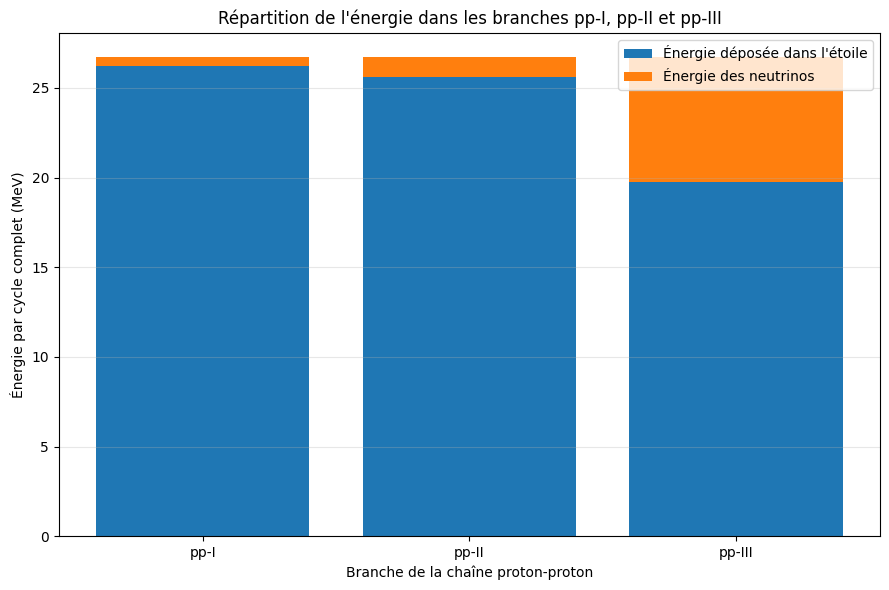

In [329]:
import matplotlib.pyplot as plt
import numpy as np

branches = comparaison_branches_pp["Branche"]
energie_deposee = comparaison_branches_pp["E_deposee_MeV"]
energie_neutrinos = comparaison_branches_pp["E_neutrinos_MeV"]
energie_totale = comparaison_branches_pp["Q_total_MeV"]

positions = np.arange(len(branches))

fig, ax = plt.subplots(figsize=(9, 6))

# Énergie déposée dans l'étoile
ax.bar(
    positions,
    energie_deposee,
    label="Énergie déposée dans l'étoile",
)

# Énergie emportée par les neutrinos
ax.bar(
    positions,
    energie_neutrinos,
    bottom=energie_deposee,
    label="Énergie des neutrinos",
)

ax.set_xticks(positions)
ax.set_xticklabels(branches)

ax.set_xlabel("Branche de la chaîne proton-proton")
ax.set_ylabel("Énergie par cycle complet (MeV)")

ax.set_title(
    "Répartition de l'énergie dans les branches pp-I, pp-II et pp-III"
)

ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

chemin_figure_simple = (
    DOSSIER_FIGURES_PP
    / "PP_Energy_Branches_Comparison_0.1.png"
)

fig.savefig(
    chemin_figure_simple,
    dpi=300,
    bbox_inches="tight",
)

print(
    f"✅ Figure sauvegardée : "
    f"{chemin_figure_simple.name}"
)

plt.show()

✅ Figure sauvegardée : PP_Energy_Branches_Annotated_0.1.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


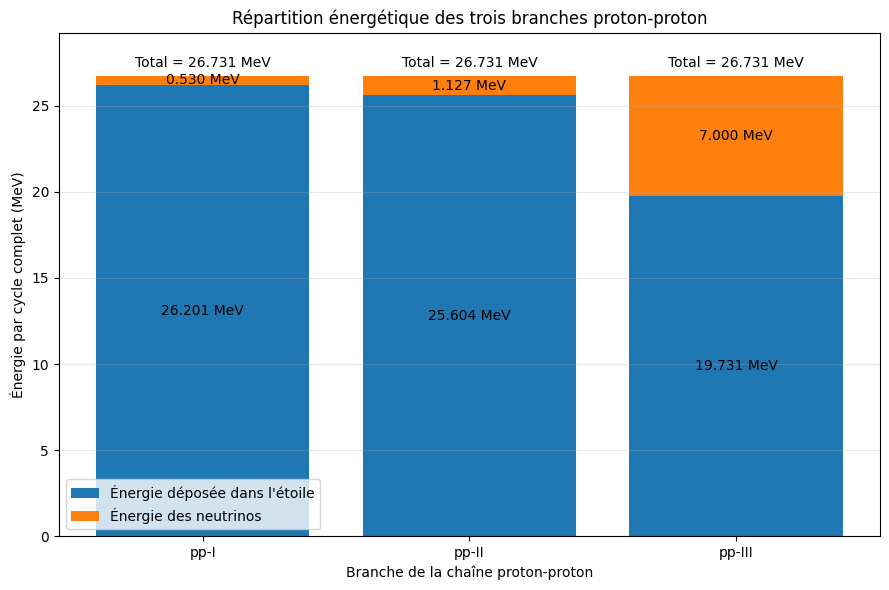

In [330]:
fig, ax = plt.subplots(figsize=(9, 6))

barres_deposees = ax.bar(
    positions,
    energie_deposee,
    label="Énergie déposée dans l'étoile",
)

barres_neutrinos = ax.bar(
    positions,
    energie_neutrinos,
    bottom=energie_deposee,
    label="Énergie des neutrinos",
)

# Valeurs de l'énergie déposée
for position, energie in zip(positions, energie_deposee):
    ax.text(
        position,
        energie / 2,
        f"{energie:.3f} MeV",
        ha="center",
        va="center",
    )

# Valeurs de l'énergie des neutrinos
for position, deposee, neutrinos in zip(
    positions,
    energie_deposee,
    energie_neutrinos,
):
    ax.text(
        position,
        deposee + neutrinos / 2,
        f"{neutrinos:.3f} MeV",
        ha="center",
        va="center",
    )

# Énergie totale au-dessus de chaque barre
for position, total in zip(
    positions,
    comparaison_branches_pp["Q_total_MeV"],
):
    ax.text(
        position,
        total + 0.35,
        f"Total = {total:.3f} MeV",
        ha="center",
        va="bottom",
    )

ax.set_xticks(positions)
ax.set_xticklabels(branches)

ax.set_xlabel("Branche de la chaîne proton-proton")
ax.set_ylabel("Énergie par cycle complet (MeV)")

ax.set_ylim(
    0,
    comparaison_branches_pp["Q_total_MeV"].max() + 2.5,
)

ax.set_title(
    "Répartition énergétique des trois branches proton-proton"
)

ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

chemin_figure_annotee = (
    DOSSIER_FIGURES_PP
    / "PP_Energy_Branches_Annotated_0.1.png"
)

fig.savefig(
    chemin_figure_annotee,
    dpi=300,
    bbox_inches="tight"
)

print(f"✅ Figure sauvegardée : {chemin_figure_annotee.name}")

plt.show()

In [331]:
assert len(branches) == 3

assert np.allclose(
    energie_deposee + energie_neutrinos,
    comparaison_branches_pp["Q_total_MeV"],
    atol=1e-6,
)

print("✅ Les trois branches sont représentées.")
print("✅ Chaque barre totalise l'énergie globale du cycle.")
print("✅ Graphique de répartition énergétique validé.")

✅ Les trois branches sont représentées.
✅ Chaque barre totalise l'énergie globale du cycle.
✅ Graphique de répartition énergétique validé.


In [332]:
# Flux de neutrinos à 1 UA
# Unité : cm^-2 s^-1

flux_pp = 5.98e10
flux_pep = 1.44e8
flux_Be7 = 4.93e9
flux_B8 = 5.46e6

In [333]:
R_ppII = flux_Be7
R_ppIII = flux_B8

R_ppI = (
    flux_pp
    + flux_pep
    - flux_Be7
    - flux_B8
) / 2

print(f"Taux relatif pp-I   : {R_ppI:.6e}")
print(f"Taux relatif pp-II  : {R_ppII:.6e}")
print(f"Taux relatif pp-III : {R_ppIII:.6e}")

Taux relatif pp-I   : 2.750427e+10
Taux relatif pp-II  : 4.930000e+09
Taux relatif pp-III : 5.460000e+06


In [334]:
R_total_pp = R_ppI + R_ppII + R_ppIII

fraction_ppI = R_ppI / R_total_pp
fraction_ppII = R_ppII / R_total_pp
fraction_ppIII = R_ppIII / R_total_pp

print(f"Fraction pp-I   : {100 * fraction_ppI:.6f} %")
print(f"Fraction pp-II  : {100 * fraction_ppII:.6f} %")
print(f"Fraction pp-III : {100 * fraction_ppIII:.6f} %")

Fraction pp-I   : 84.785755 %
Fraction pp-II  : 15.197414 %
Fraction pp-III : 0.016831 %


In [335]:
proportions_branches_solaires = pd.DataFrame({
    "Branche": [
        "pp-I",
        "pp-II",
        "pp-III",
    ],

    "Taux_relatif": [
        R_ppI,
        R_ppII,
        R_ppIII,
    ],

    "Fraction_cycles": [
        fraction_ppI,
        fraction_ppII,
        fraction_ppIII,
    ],

    "Fraction_cycles_pct": [
        100 * fraction_ppI,
        100 * fraction_ppII,
        100 * fraction_ppIII,
    ],
})

proportions_branches_solaires

,Branche,Taux_relatif,Fraction_cycles,Fraction_cycles_pct
0,pp-I,2.750427e+10,0.847858,84.785755
1,pp-II,4.930000e+09,0.151974,15.197414
2,pp-III,5.460000e+06,0.000168,0.016831


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [336]:
assert R_ppI > 0
assert R_ppII > 0
assert R_ppIII > 0

assert np.isclose(
    fraction_ppI + fraction_ppII + fraction_ppIII,
    1.0,
    atol=1e-12,
)

assert fraction_ppI > fraction_ppII > fraction_ppIII

assert np.isclose(
    100 * fraction_ppI,
    84.785755,
    atol=1e-5,
)

assert np.isclose(
    100 * fraction_ppII,
    15.197414,
    atol=1e-5,
)

assert np.isclose(
    100 * fraction_ppIII,
    0.016831,
    atol=1e-5,
)

print("✅ Les proportions totalisent 100 %.")
print("✅ pp-I est la terminaison dominante dans le Soleil.")
print("✅ pp-II constitue la branche secondaire.")
print("✅ pp-III est extrêmement rare.")
print("✅ Proportions solaires des branches pp validées.")

✅ Les proportions totalisent 100 %.
✅ pp-I est la terminaison dominante dans le Soleil.
✅ pp-II constitue la branche secondaire.
✅ pp-III est extrêmement rare.
✅ Proportions solaires des branches pp validées.


In [337]:
bilan_pp_solaire = comparaison_branches_pp.merge(
    proportions_branches_solaires[
        [
            "Branche",
            "Fraction_cycles",
            "Fraction_cycles_pct",
        ]
    ],
    on="Branche",
    how="inner",
)

bilan_pp_solaire

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Branche,Produits caractéristiques,Q_total_MeV,E_neutrinos_MeV,E_deposee_MeV,Fraction_neutrinos_pct,Fraction_deposee_pct,Fraction_cycles,Fraction_cycles_pct
0,pp-I,He-3 + He-3 → He-4 + 2p,26.731023,0.530000,26.201023,1.982715,98.017285,0.847858,84.785755
1,pp-II,Be-7 + e⁻ → Li-7 + νₑ,26.731023,1.126893,25.604130,4.215675,95.784325,0.151974,15.197414
2,pp-III,B-8 → Be-8 + e⁺ + νₑ,26.731023,7.000000,19.731023,26.186802,73.813198,0.000168,0.016831


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [338]:
bilan_pp_solaire["Contribution_deposee_MeV"] = (
    bilan_pp_solaire["Fraction_cycles"]
    * bilan_pp_solaire["E_deposee_MeV"]
)

bilan_pp_solaire["Contribution_neutrinos_MeV"] = (
    bilan_pp_solaire["Fraction_cycles"]
    * bilan_pp_solaire["E_neutrinos_MeV"]
)

bilan_pp_solaire[
    [
        "Branche",
        "Fraction_cycles_pct",
        "Contribution_deposee_MeV",
        "Contribution_neutrinos_MeV",
    ]
].round(6)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Branche,Fraction_cycles_pct,Contribution_deposee_MeV,Contribution_neutrinos_MeV
0,pp-I,84.785755,22.214735,0.449365
1,pp-II,15.197414,3.891166,0.171259
2,pp-III,0.016831,0.003321,0.001178


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [339]:
E_deposee_moyenne_solaire_MeV = (
    bilan_pp_solaire["Contribution_deposee_MeV"].sum()
)

E_neutrinos_moyenne_solaire_MeV = (
    bilan_pp_solaire["Contribution_neutrinos_MeV"].sum()
)

E_totale_moyenne_solaire_MeV = (
    E_deposee_moyenne_solaire_MeV
    + E_neutrinos_moyenne_solaire_MeV
)

fraction_neutrinos_solaire_pct = (
    100
    * E_neutrinos_moyenne_solaire_MeV
    / E_totale_moyenne_solaire_MeV
)

fraction_deposee_solaire_pct = (
    100
    * E_deposee_moyenne_solaire_MeV
    / E_totale_moyenne_solaire_MeV
)

print(
    f"Énergie moyenne déposée par cycle solaire : "
    f"{E_deposee_moyenne_solaire_MeV:.6f} MeV"
)

print(
    f"Énergie moyenne emportée par les neutrinos : "
    f"{E_neutrinos_moyenne_solaire_MeV:.6f} MeV"
)

print(
    f"Énergie totale moyenne : "
    f"{E_totale_moyenne_solaire_MeV:.6f} MeV"
)

print(
    f"Fraction solaire emportée par les neutrinos : "
    f"{fraction_neutrinos_solaire_pct:.3f} %"
)

print(
    f"Fraction solaire déposée dans l'étoile : "
    f"{fraction_deposee_solaire_pct:.3f} %"
)

Énergie moyenne déposée par cycle solaire : 26.109222 MeV
Énergie moyenne emportée par les neutrinos : 0.621801 MeV
Énergie totale moyenne : 26.731023 MeV
Fraction solaire emportée par les neutrinos : 2.326 %
Fraction solaire déposée dans l'étoile : 97.674 %


In [340]:
bilan_pp_solaire["Part_energie_deposee_pct"] = (
    100
    * bilan_pp_solaire["Contribution_deposee_MeV"]
    / E_deposee_moyenne_solaire_MeV
)

bilan_pp_solaire[
    [
        "Branche",
        "Fraction_cycles_pct",
        "Part_energie_deposee_pct",
    ]
].round(6)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Branche,Fraction_cycles_pct,Part_energie_deposee_pct
0,pp-I,84.785755,85.083866
1,pp-II,15.197414,14.903415
2,pp-III,0.016831,0.012720


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [341]:
assert np.isclose(
    bilan_pp_solaire["Fraction_cycles"].sum(),
    1.0,
    atol=1e-12,
)

assert np.isclose(
    E_totale_moyenne_solaire_MeV,
    26.731023,
    atol=1e-6,
)

assert np.isclose(
    E_deposee_moyenne_solaire_MeV
    + E_neutrinos_moyenne_solaire_MeV,
    E_totale_moyenne_solaire_MeV,
    atol=1e-12,
)

assert np.isclose(
    bilan_pp_solaire["Part_energie_deposee_pct"].sum(),
    100.0,
    atol=1e-9,
)

assert (
    bilan_pp_solaire.loc[
        bilan_pp_solaire["Branche"] == "pp-I",
        "Part_energie_deposee_pct",
    ].iloc[0]
    >
    bilan_pp_solaire.loc[
        bilan_pp_solaire["Branche"] == "pp-II",
        "Part_energie_deposee_pct",
    ].iloc[0]
    >
    bilan_pp_solaire.loc[
        bilan_pp_solaire["Branche"] == "pp-III",
        "Part_energie_deposee_pct",
    ].iloc[0]
)

print("✅ Pondération solaire des trois branches effectuée.")
print("✅ Le bilan total moyen reste égal à 26.731023 MeV.")
print("✅ Énergie moyenne des neutrinos solaires calculée.")
print("✅ Énergie moyenne déposée dans le Soleil calculée.")
print("✅ Contributions énergétiques relatives validées.")

✅ Pondération solaire des trois branches effectuée.
✅ Le bilan total moyen reste égal à 26.731023 MeV.
✅ Énergie moyenne des neutrinos solaires calculée.
✅ Énergie moyenne déposée dans le Soleil calculée.
✅ Contributions énergétiques relatives validées.


In [342]:
colonnes_contributions = [
    "Branche",
    "Fraction_cycles_pct",
    "E_deposee_MeV",
    "E_neutrinos_MeV",
    "Contribution_deposee_MeV",
    "Contribution_neutrinos_MeV",
    "Part_energie_deposee_pct",
]

bilan_pp_solaire[colonnes_contributions].round({
    "Fraction_cycles_pct": 6,
    "E_deposee_MeV": 6,
    "E_neutrinos_MeV": 6,
    "Contribution_deposee_MeV": 6,
    "Contribution_neutrinos_MeV": 6,
    "Part_energie_deposee_pct": 6,
})

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Branche,Fraction_cycles_pct,E_deposee_MeV,E_neutrinos_MeV,Contribution_deposee_MeV,Contribution_neutrinos_MeV,Part_energie_deposee_pct
0,pp-I,84.785755,26.201023,0.530000,22.214735,0.449365,85.083866
1,pp-II,15.197414,25.604130,1.126893,3.891166,0.171259,14.903415
2,pp-III,0.016831,19.731023,7.000000,0.003321,0.001178,0.012720


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


✅ Figure sauvegardée : PP_Solar_Weighted_Contributions_0.1.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


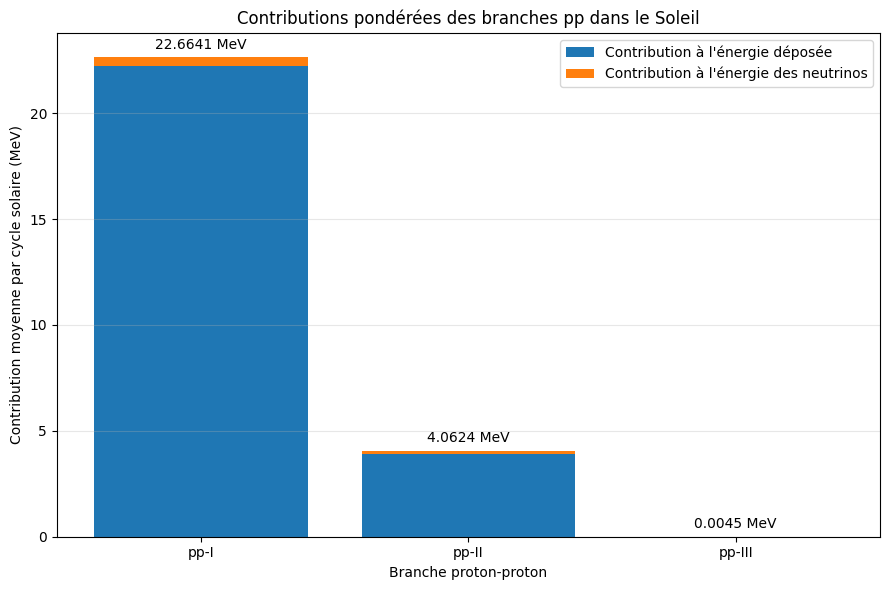

In [343]:
import matplotlib.pyplot as plt
import numpy as np

branches_solaires = bilan_pp_solaire["Branche"]
positions_solaires = np.arange(len(branches_solaires))

contribution_deposee = (
    bilan_pp_solaire["Contribution_deposee_MeV"]
)

contribution_neutrinos = (
    bilan_pp_solaire["Contribution_neutrinos_MeV"]
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.bar(
    positions_solaires,
    contribution_deposee,
    label="Contribution à l'énergie déposée",
)

ax.bar(
    positions_solaires,
    contribution_neutrinos,
    bottom=contribution_deposee,
    label="Contribution à l'énergie des neutrinos",
)

for position, deposee, neutrinos in zip(
    positions_solaires,
    contribution_deposee,
    contribution_neutrinos,
):
    total = deposee + neutrinos

    ax.text(
        position,
        total + 0.25,
        f"{total:.4f} MeV",
        ha="center",
        va="bottom",
    )

ax.set_xticks(positions_solaires)
ax.set_xticklabels(branches_solaires)

ax.set_xlabel("Branche proton-proton")
ax.set_ylabel("Contribution moyenne par cycle solaire (MeV)")

ax.set_title(
    "Contributions pondérées des branches pp dans le Soleil"
)

ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

chemin_figure_solaire = (
    DOSSIER_FIGURES_PP
    / "PP_Solar_Weighted_Contributions_0.1.png"
)

fig.savefig(
    chemin_figure_solaire,
    dpi=300,
    bbox_inches="tight"
)

print(f"✅ Figure sauvegardée : {chemin_figure_solaire.name}")

plt.show()


/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetim

✅ Figure sauvegardée : PP_Solar_Weighted_Contributions_Log_0.1.png


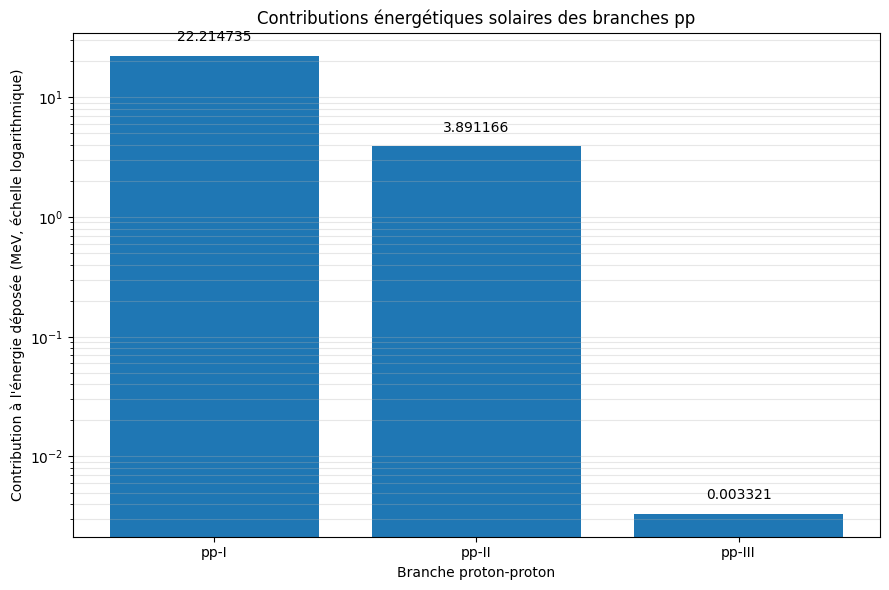

In [344]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.bar(
    positions_solaires,
    contribution_deposee,
)

ax.set_yscale("log")

ax.set_xticks(positions_solaires)
ax.set_xticklabels(branches_solaires)

ax.set_xlabel("Branche proton-proton")
ax.set_ylabel(
    "Contribution à l'énergie déposée "
    "(MeV, échelle logarithmique)"
)

ax.set_title(
    "Contributions énergétiques solaires des branches pp"
)

ax.grid(
    axis="y",
    which="both",
    alpha=0.3,
)

for position, valeur in zip(
    positions_solaires,
    contribution_deposee,
):
    ax.text(
        position,
        valeur * 1.25,
        f"{valeur:.6f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()

chemin_figure_solaire_log = (
    DOSSIER_FIGURES_PP
    / "PP_Solar_Weighted_Contributions_Log_0.1.png"
)

fig.savefig(
    chemin_figure_solaire_log,
    dpi=300,
    bbox_inches="tight"
)

print(f"✅ Figure sauvegardée : {chemin_figure_solaire_log.name}")

plt.show()

In [345]:
assert np.all(
    bilan_pp_solaire["Contribution_deposee_MeV"] > 0
)

assert np.all(
    bilan_pp_solaire["Contribution_neutrinos_MeV"] > 0
)

assert np.isclose(
    bilan_pp_solaire["Contribution_deposee_MeV"].sum(),
    E_deposee_moyenne_solaire_MeV,
    atol=1e-10,
)

assert np.isclose(
    bilan_pp_solaire["Contribution_neutrinos_MeV"].sum(),
    E_neutrinos_moyenne_solaire_MeV,
    atol=1e-10,
)

print("✅ Contributions pondérées représentées.")
print("✅ La somme déposée retrouve la moyenne solaire.")
print("✅ La somme des neutrinos retrouve la moyenne solaire.")
print("✅ Comparaison énergétique solaire validée.")

✅ Contributions pondérées représentées.
✅ La somme déposée retrouve la moyenne solaire.
✅ La somme des neutrinos retrouve la moyenne solaire.
✅ Comparaison énergétique solaire validée.


In [346]:
from PIL import Image

figures_pp = [
    chemin_figure_simple,
    chemin_figure_annotee,
    chemin_figure_solaire,
    chemin_figure_solaire_log,
]

for chemin in figures_pp:
    assert chemin.exists(), f"Figure absente : {chemin.name}"
    assert chemin.stat().st_size > 0, f"Figure vide : {chemin.name}"

    with Image.open(chemin) as image:
        print(
            f"✅ {chemin.name} | "
            f"{chemin.stat().st_size} octets | "
            f"{image.size} | {image.format}"
        )

print("✅ Les quatre figures pp ont été générées et validées.")

✅ PP_Energy_Branches_Comparison_0.1.png | 112389 octets | (2671, 1766) | PNG
✅ PP_Energy_Branches_Annotated_0.1.png | 156703 octets | (2671, 1766) | PNG
✅ PP_Solar_Weighted_Contributions_0.1.png | 141111 octets | (2670, 1766) | PNG
✅ PP_Solar_Weighted_Contributions_Log_0.1.png | 127369 octets | (2666, 1766) | PNG
✅ Les quatre figures pp ont été générées et validées.


In [347]:
# ---------------------------------------------------------
# Production nucléaire nécessaire à la luminosité solaire
# ---------------------------------------------------------

L_solaire_W = 3.828e26

MeV_vers_J = 1.602176634e-13

E_deposee_cycle_J = (
    E_deposee_moyenne_solaire_MeV
    * MeV_vers_J
)

cycles_pp_par_seconde = (
    L_solaire_W
    / E_deposee_cycle_J
)

print(
    f"Énergie déposée par cycle : "
    f"{E_deposee_cycle_J:.6e} J"
)

print(
    f"Cycles proton-proton par seconde : "
    f"{cycles_pp_par_seconde:.6e} s⁻¹"
)

Énergie déposée par cycle : 4.183158e-12 J
Cycles proton-proton par seconde : 9.150980e+37 s⁻¹


In [348]:
protons_consommes_par_seconde = (
    4 * cycles_pp_par_seconde
)

noyaux_He4_produits_par_seconde = (
    cycles_pp_par_seconde
)

print(
    f"Protons consommés par seconde : "
    f"{protons_consommes_par_seconde:.6e} s⁻¹"
)

print(
    f"Noyaux d'hélium-4 produits par seconde : "
    f"{noyaux_He4_produits_par_seconde:.6e} s⁻¹"
)

Protons consommés par seconde : 3.660392e+38 s⁻¹
Noyaux d'hélium-4 produits par seconde : 9.150980e+37 s⁻¹


In [349]:
masse_protons_consommee_kg_s = (
    protons_consommes_par_seconde
    * m_p
)

masse_He4_produite_kg_s = (
    noyaux_He4_produits_par_seconde
    * masse_He4_u
    * m_u
)

print(
    f"Masse de protons consommée : "
    f"{masse_protons_consommee_kg_s:.6e} kg/s"
)

print(
    f"Masse d'hélium-4 produite : "
    f"{masse_He4_produite_kg_s:.6e} kg/s"
)

Masse de protons consommée : 6.122452e+11 kg/s
Masse d'hélium-4 produite : 6.080513e+11 kg/s


In [350]:
masse_convertie_lumiere_kg_s = (
    L_solaire_W
    / c**2
)

print(
    f"Masse équivalente à la luminosité solaire : "
    f"{masse_convertie_lumiere_kg_s:.6e} kg/s"
)

Masse équivalente à la luminosité solaire : 4.259224e+09 kg/s


In [351]:
puissance_neutrinos_W = (
    cycles_pp_par_seconde
    * E_neutrinos_moyenne_solaire_MeV
    * MeV_vers_J
)

puissance_nucleaire_totale_W = (
    L_solaire_W
    + puissance_neutrinos_W
)

masse_convertie_totale_kg_s = (
    puissance_nucleaire_totale_W
    / c**2
)

masse_convertie_neutrinos_kg_s = (
    puissance_neutrinos_W
    / c**2
)

print(
    f"Puissance emportée par les neutrinos : "
    f"{puissance_neutrinos_W:.6e} W"
)

print(
    f"Puissance nucléaire totale : "
    f"{puissance_nucleaire_totale_W:.6e} W"
)

print(
    f"Masse convertie en lumière : "
    f"{masse_convertie_lumiere_kg_s:.6e} kg/s"
)

print(
    f"Masse convertie en énergie des neutrinos : "
    f"{masse_convertie_neutrinos_kg_s:.6e} kg/s"
)

print(
    f"Masse totale convertie en énergie : "
    f"{masse_convertie_totale_kg_s:.6e} kg/s"
)

Puissance emportée par les neutrinos : 9.116531e+24 W
Puissance nucléaire totale : 3.919165e+26 W
Masse convertie en lumière : 4.259224e+09 kg/s
Masse convertie en énergie des neutrinos : 1.014351e+08 kg/s
Masse totale convertie en énergie : 4.360660e+09 kg/s


In [352]:
assert cycles_pp_par_seconde > 0

assert np.isclose(
    protons_consommes_par_seconde,
    4 * noyaux_He4_produits_par_seconde,
    rtol=1e-12,
)

assert np.isclose(
    cycles_pp_par_seconde * E_deposee_cycle_J,
    L_solaire_W,
    rtol=1e-12,
)

assert np.isclose(
    puissance_nucleaire_totale_W,
    L_solaire_W + puissance_neutrinos_W,
    rtol=1e-12,
)

assert np.isclose(
    masse_convertie_totale_kg_s,
    (
        masse_convertie_lumiere_kg_s
        + masse_convertie_neutrinos_kg_s
    ),
    rtol=1e-12,
)

assert masse_protons_consommee_kg_s > masse_He4_produite_kg_s

print("✅ Nombre de cycles proton-proton calculé.")
print("✅ Consommation de protons calculée.")
print("✅ Production d'hélium-4 calculée.")
print("✅ Puissance des neutrinos calculée.")
print("✅ Masse totale convertie en énergie calculée.")

✅ Nombre de cycles proton-proton calculé.
✅ Consommation de protons calculée.
✅ Production d'hélium-4 calculée.
✅ Puissance des neutrinos calculée.
✅ Masse totale convertie en énergie calculée.


In [353]:
electrons_consommes_par_seconde = (
    2 * cycles_pp_par_seconde
)

masse_electrons_consommee_kg_s = (
    electrons_consommes_par_seconde
    * m_e
)

print(
    f"Électrons consommés par seconde : "
    f"{electrons_consommes_par_seconde:.6e} s⁻¹"
)

print(
    f"Masse des électrons consommés : "
    f"{masse_electrons_consommee_kg_s:.6e} kg/s"
)

Électrons consommés par seconde : 1.830196e+38 s⁻¹
Masse des électrons consommés : 1.667196e+08 kg/s


In [354]:
masse_initiale_reactifs_kg_s = (
    masse_protons_consommee_kg_s
    + masse_electrons_consommee_kg_s
)

defaut_masse_direct_kg_s = (
    masse_initiale_reactifs_kg_s
    - masse_He4_produite_kg_s
)

print(
    f"Masse initiale totale des réactifs : "
    f"{masse_initiale_reactifs_kg_s:.6e} kg/s"
)

print(
    f"Masse finale sous forme d'hélium : "
    f"{masse_He4_produite_kg_s:.6e} kg/s"
)

print(
    f"Défaut de masse direct : "
    f"{defaut_masse_direct_kg_s:.6e} kg/s"
)

Masse initiale totale des réactifs : 6.124119e+11 kg/s
Masse finale sous forme d'hélium : 6.080513e+11 kg/s
Défaut de masse direct : 4.360659e+09 kg/s


In [355]:
ecart_bilan_masse_kg_s = (
    defaut_masse_direct_kg_s
    - masse_convertie_totale_kg_s
)

ecart_relatif_bilan_masse = (
    abs(ecart_bilan_masse_kg_s)
    / masse_convertie_totale_kg_s
)

print(
    f"Masse convertie par différence des masses : "
    f"{defaut_masse_direct_kg_s:.6e} kg/s"
)

print(
    f"Masse convertie par E/c² : "
    f"{masse_convertie_totale_kg_s:.6e} kg/s"
)

print(
    f"Écart absolu : "
    f"{ecart_bilan_masse_kg_s:.6e} kg/s"
)

print(
    f"Écart relatif : "
    f"{100 * ecart_relatif_bilan_masse:.6f} %"
)

Masse convertie par différence des masses : 4.360659e+09 kg/s
Masse convertie par E/c² : 4.360660e+09 kg/s
Écart absolu : -3.768585e+01 kg/s
Écart relatif : 0.000001 %


In [356]:
assert electrons_consommes_par_seconde > 0
assert masse_electrons_consommee_kg_s > 0

assert np.isclose(
    electrons_consommes_par_seconde,
    2 * noyaux_He4_produits_par_seconde,
    rtol=1e-12,
)

assert np.isclose(
    masse_initiale_reactifs_kg_s,
    (
        masse_protons_consommee_kg_s
        + masse_electrons_consommee_kg_s
    ),
    rtol=1e-12,
)

assert defaut_masse_direct_kg_s > 0

assert np.isclose(
    defaut_masse_direct_kg_s,
    masse_convertie_totale_kg_s,
    rtol=1e-3,
)

print("✅ Masse des électrons intégrée au bilan.")
print("✅ Défaut de masse direct calculé.")
print("✅ Bilan de masse cohérent avec E = mc².")
print("✅ Fermeture globale de la chaîne proton-proton validée.")

✅ Masse des électrons intégrée au bilan.
✅ Défaut de masse direct calculé.
✅ Bilan de masse cohérent avec E = mc².
✅ Fermeture globale de la chaîne proton-proton validée.


# Conclusion — Chaîne proton-proton

Ce notebook a reconstruit quantitativement les trois principales branches de la chaîne proton-proton à partir des masses nucléaires AME2020 et des constantes physiques CODATA.

Les branches pp-I, pp-II et pp-III conduisent toutes à la même réaction globale :

\[
4p + 2e^-
\longrightarrow
{}^{4}\mathrm{He} + 2\nu_e,
\]

avec une énergie totale libérée :

\[
Q_{\mathrm{total}}
=
26.731023\ \mathrm{MeV}.
\]

La différence entre les branches réside principalement dans l’énergie emportée par les neutrinos.

Les résultats obtenus sont :

| Branche | Énergie déposée | Énergie des neutrinos |
|---|---:|---:|
| pp-I | 26.201023 MeV | 0.530000 MeV |
| pp-II | 25.604130 MeV | 1.126893 MeV |
| pp-III | 19.731023 MeV | 7.000000 MeV |

À partir des flux solaires de neutrinos, les fractions estimées des cycles sont :

\[
f_{\mathrm{ppI}}
=
84.785755\%,
\]

\[
f_{\mathrm{ppII}}
=
15.197414\%,
\]

\[
f_{\mathrm{ppIII}}
=
0.016831\%.
\]

L’énergie moyenne déposée dans le Soleil par cycle est :

\[
\langle E_{\mathrm{déposée}}\rangle
=
26.109222\ \mathrm{MeV},
\]

tandis que l’énergie moyenne emportée par les neutrinos est :

\[
\langle E_{\nu}\rangle
=
0.621801\ \mathrm{MeV}.
\]

Pour fournir la luminosité solaire nominale,

\[
L_\odot
=
3.828\times10^{26}\ \mathrm{W},
\]

le Soleil doit réaliser environ :

\[
9.150980\times10^{37}
\]

cycles proton-proton par seconde.

Cela correspond à :

\[
3.660392\times10^{38}
\]

protons consommés par seconde et à :

\[
9.150980\times10^{37}
\]

noyaux d’hélium-4 produits par seconde.

La masse totale initiale des protons et des électrons est :

\[
6.124119\times10^{11}\ \mathrm{kg/s},
\]

et la masse d’hélium-4 produite est :

\[
6.080513\times10^{11}\ \mathrm{kg/s}.
\]

Le défaut de masse direct vaut :

\[
\Delta \dot M
=
4.360659\times10^{9}\ \mathrm{kg/s}.
\]

La masse équivalente calculée indépendamment à partir de la puissance nucléaire totale est :

\[
\frac{P_{\mathrm{nucléaire}}}{c^2}
=
4.360660\times10^{9}\ \mathrm{kg/s}.
\]

L’écart relatif entre les deux méthodes est de l’ordre de :

\[
10^{-6}\%.
\]

La fermeture du bilan masse-énergie est donc validée avec une excellente précision numérique.

Les résultats vérifient :

- la conservation du nombre baryonique ;
- la conservation de la charge électrique ;
- la conservation du nombre leptonique ;
- la cohérence du bilan énergétique ;
- la relation \(E=\Delta mc^2\).

La chaîne proton-proton est ainsi reconstruite, quantifiée et validée de manière reproductible.

In [357]:
from pathlib import Path

# Racine du dépôt GitHub
DOSSIER_DEPOT = Path("/content/Univers")
RACINE_DEPOT = DOSSIER_DEPOT / "gvh_dynamic"

# Dossier des exports de la chaîne proton-proton
DOSSIER_PP = RACINE_DEPOT / "Data" / "Nuclear" / "pp_chain"
DOSSIER_PP.mkdir(parents=True, exist_ok=True)

print("Racine :", RACINE_DEPOT)
print("Exports :", DOSSIER_PP)

Racine : /content/Univers/gvh_dynamic
Exports : /content/Univers/gvh_dynamic/Data/Nuclear/pp_chain


In [358]:
from pathlib import Path

DOSSIER_PP = RACINE_DEPOT / "Data" / "Nuclear" / "pp_chain"
DOSSIER_PP.mkdir(parents=True, exist_ok=True)

print(f"Dossier d'export : {DOSSIER_PP}")

Dossier d'export : /content/Univers/gvh_dynamic/Data/Nuclear/pp_chain


In [359]:
from pathlib import Path

# Racine du dépôt GitHub
DOSSIER_DEPOT = Path("/content/Univers")
RACINE_DEPOT = DOSSIER_DEPOT / "gvh_dynamic"

# Dossier des exports de la chaîne proton-proton
DOSSIER_PP = RACINE_DEPOT / "Data" / "Nuclear" / "pp_chain"
DOSSIER_PP.mkdir(parents=True, exist_ok=True)

print("Racine :", RACINE_DEPOT)
print("Exports :", DOSSIER_PP)

Racine : /content/Univers/gvh_dynamic
Exports : /content/Univers/gvh_dynamic/Data/Nuclear/pp_chain


In [360]:
import pandas as pd

In [361]:
import pandas as pd

for nom, objet in list(globals().items()):
    if isinstance(objet, pd.DataFrame):
        print(f"{nom:40s} {objet.shape}")

__                                       (6, 9)
___                                      (6, 8)
df_codata                                (355, 7)
_11                                      (10, 6)
_12                                      (10, 4)
_13                                      (10, 7)
df_constantes_essentielles               (10, 5)
_14                                      (0, 5)
_15                                      (10, 7)
_16                                      (10, 5)
df_ame2020                               (3558, 21)
_31                                      (15, 16)
df_controle_ame                          (6, 8)
_33                                      (6, 8)
_39                                      (6, 9)
df_ame_mesure                            (2328, 21)
df_ame_extrapole                         (1230, 21)
top_noyaux_lies                          (15, 6)
_44                                      (15, 6)
df_reperes                               (8, 21)
branches_pp    

In [362]:
chemin_branches = (
    DOSSIER_PP
    / "PP_Branches_Comparison_0.1.csv"
)

comparaison_branches_pp.to_csv(
    chemin_branches,
    index=False
)

print(f"Export terminé : {chemin_branches.name}")
print(comparaison_branches_pp.shape)

Export terminé : PP_Branches_Comparison_0.1.csv
(3, 7)


In [363]:
chemin_proportions = (
    DOSSIER_PP
    / "PP_Solar_Branch_Proportions_0.1.csv"
)

proportions_branches_solaires.to_csv(
    chemin_proportions,
    index=False
)

print(f"Export terminé : {chemin_proportions.name}")
print(proportions_branches_solaires.shape)

Export terminé : PP_Solar_Branch_Proportions_0.1.csv
(3, 4)


In [364]:
chemin_bilan_solaire = (
    DOSSIER_PP
    / "PP_Solar_Weighted_Energy_0.1.csv"
)

bilan_pp_solaire.to_csv(
    chemin_bilan_solaire,
    index=False
)

print(f"Export terminé : {chemin_bilan_solaire.name}")
print(bilan_pp_solaire.shape)

Export terminé : PP_Solar_Weighted_Energy_0.1.csv
(3, 12)


In [365]:
fichiers_exportes_pp = [
    chemin_branches,
    chemin_proportions,
    chemin_bilan_solaire,
]

for fichier in fichiers_exportes_pp:
    assert fichier.exists(), f"Fichier manquant : {fichier}"
    assert fichier.stat().st_size > 0, f"Fichier vide : {fichier}"

    print(
        f"✅ {fichier.name} — "
        f"{fichier.stat().st_size} octets"
    )

✅ PP_Branches_Comparison_0.1.csv — 422 octets
✅ PP_Solar_Branch_Proportions_0.1.csv — 228 octets
✅ PP_Solar_Weighted_Energy_0.1.csv — 827 octets


In [366]:
production_solaire_pp = pd.DataFrame(
    {
        "Grandeur": [
            "Luminosité solaire",
            "Énergie déposée moyenne par cycle",
            "Cycles proton-proton par seconde",
            "Protons consommés par seconde",
            "Électrons consommés par seconde",
            "Noyaux He-4 produits par seconde",
            "Masse de protons consommée",
            "Masse d'électrons consommée",
            "Masse initiale totale des réactifs",
            "Masse d'He-4 produite",
        ],
        "Valeur": [
            L_solaire_W,
            E_deposee_cycle_J,
            cycles_pp_par_seconde,
            protons_consommes_par_seconde,
            electrons_consommes_par_seconde,
            noyaux_He4_produits_par_seconde,
            masse_protons_consommee_kg_s,
            masse_electrons_consommee_kg_s,
            masse_initiale_reactifs_kg_s,
            masse_He4_produite_kg_s,
        ],
        "Unite": [
            "W",
            "J/cycle",
            "cycles/s",
            "protons/s",
            "electrons/s",
            "noyaux/s",
            "kg/s",
            "kg/s",
            "kg/s",
            "kg/s",
        ],
    }
)

display(production_solaire_pp)

,Grandeur,Valeur,Unite
0,Luminosité solaire,3.828000e+26,W
1,Énergie déposée moyenne par cycle,4.183158e-12,J/cycle
2,Cycles proton-proton par seconde,9.150980e+37,cycles/s
3,Protons consommés par seconde,3.660392e+38,protons/s
4,Électrons consommés par seconde,1.830196e+38,electrons/s
5,Noyaux He-4 produits par seconde,9.150980e+37,noyaux/s
6,Masse de protons consommée,6.122452e+11,kg/s
7,Masse d'électrons consommée,1.667196e+08,kg/s
8,Masse initiale totale des réactifs,6.124119e+11,kg/s
9,Masse d'He-4 produite,6.080513e+11,kg/s


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [367]:
chemin_production_solaire = (
    DOSSIER_PP
    / "PP_Solar_Cycle_Production_0.1.csv"
)

production_solaire_pp.to_csv(
    chemin_production_solaire,
    index=False,
)

assert chemin_production_solaire.exists()
assert chemin_production_solaire.stat().st_size > 0

print(
    f"✅ {chemin_production_solaire.name} — "
    f"{chemin_production_solaire.stat().st_size} octets"
)

✅ PP_Solar_Cycle_Production_0.1.csv — 591 octets


In [368]:
bilan_masse_energie_pp = pd.DataFrame(
    {
        "Grandeur": [
            "Puissance électromagnétique",
            "Puissance emportée par les neutrinos",
            "Puissance nucléaire totale",
            "Masse convertie en lumière",
            "Masse convertie en énergie des neutrinos",
            "Masse totale convertie par E/c²",
            "Défaut de masse direct",
            "Écart absolu entre les deux méthodes",
            "Écart relatif entre les deux méthodes",
        ],
        "Valeur": [
            L_solaire_W,
            puissance_neutrinos_W,
            puissance_nucleaire_totale_W,
            masse_convertie_lumiere_kg_s,
            masse_convertie_neutrinos_kg_s,
            masse_convertie_totale_kg_s,
            defaut_masse_direct_kg_s,
            ecart_bilan_masse_kg_s,
            ecart_relatif_bilan_masse,
        ],
        "Unite": [
            "W",
            "W",
            "W",
            "kg/s",
            "kg/s",
            "kg/s",
            "kg/s",
            "kg/s",
            "fraction",
        ],
    }
)

display(bilan_masse_energie_pp)

,Grandeur,Valeur,Unite
0,Puissance électromagnétique,3.828000e+26,W
1,Puissance emportée par les neutrinos,9.116531e+24,W
2,Puissance nucléaire totale,3.919165e+26,W
3,Masse convertie en lumière,4.259224e+09,kg/s
4,Masse convertie en énergie des neutrinos,1.014351e+08,kg/s
5,Masse totale convertie par E/c²,4.360660e+09,kg/s
6,Défaut de masse direct,4.360659e+09,kg/s
7,Écart absolu entre les deux méthodes,-3.768585e+01,kg/s
8,Écart relatif entre les deux méthodes,8.642235e-09,fraction


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [369]:
chemin_bilan_masse_energie = (
    DOSSIER_PP
    / "PP_Mass_Energy_Balance_0.1.csv"
)

bilan_masse_energie_pp.to_csv(
    chemin_bilan_masse_energie,
    index=False,
)

assert chemin_bilan_masse_energie.exists()
assert chemin_bilan_masse_energie.stat().st_size > 0

print(
    f"✅ {chemin_bilan_masse_energie.name} — "
    f"{chemin_bilan_masse_energie.stat().st_size} octets"
)

✅ PP_Mass_Energy_Balance_0.1.csv — 534 octets


In [370]:
fichiers_csv_pp = [
    DOSSIER_PP / "PP_Branches_Comparison_0.1.csv",
    DOSSIER_PP / "PP_Solar_Branch_Proportions_0.1.csv",
    DOSSIER_PP / "PP_Solar_Weighted_Energy_0.1.csv",
    DOSSIER_PP / "PP_Solar_Cycle_Production_0.1.csv",
    DOSSIER_PP / "PP_Mass_Energy_Balance_0.1.csv",
]

print("Vérification globale des exports :\n")

for fichier in fichiers_csv_pp:
    assert fichier.exists(), f"Fichier manquant : {fichier.name}"
    assert fichier.stat().st_size > 0, f"Fichier vide : {fichier.name}"

    df_controle = pd.read_csv(fichier)

    assert not df_controle.empty, (
        f"CSV vide après relecture : {fichier.name}"
    )

    print(
        f"✅ {fichier.name:42s} "
        f"{df_controle.shape} — "
        f"{fichier.stat().st_size} octets"
    )

print("\n✅ Les cinq CSV ont été exportés et relus correctement.")
print("✅ Export scientifique de la chaîne proton-proton terminé.")

Vérification globale des exports :

✅ PP_Branches_Comparison_0.1.csv             (3, 7) — 422 octets
✅ PP_Solar_Branch_Proportions_0.1.csv        (3, 4) — 228 octets
✅ PP_Solar_Weighted_Energy_0.1.csv           (3, 12) — 827 octets
✅ PP_Solar_Cycle_Production_0.1.csv          (10, 3) — 591 octets
✅ PP_Mass_Energy_Balance_0.1.csv             (9, 3) — 534 octets

✅ Les cinq CSV ont été exportés et relus correctement.
✅ Export scientifique de la chaîne proton-proton terminé.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [371]:
from pathlib import Path

print("=== CSV ===")
for f in sorted((RACINE_DEPOT / "Data" / "Nuclear" / "pp_chain").glob("*.csv")):
    print("✅", f.name)

print("\n=== Figures ===")
for f in sorted((RACINE_DEPOT / "Figures" / "Nuclear" / "pp_chain").glob("*.png")):
    print("✅", f.name)

=== CSV ===
✅ PP_Branches_Comparison_0.1.csv
✅ PP_Mass_Energy_Balance_0.1.csv
✅ PP_Solar_Branch_Proportions_0.1.csv
✅ PP_Solar_Cycle_Production_0.1.csv
✅ PP_Solar_Weighted_Energy_0.1.csv

=== Figures ===
✅ PP_Energy_Branches_Annotated_0.1.png
✅ PP_Energy_Branches_Comparison_0.1.png
✅ PP_Solar_Weighted_Contributions_0.1.png
✅ PP_Solar_Weighted_Contributions_Log_0.1.png
